In [1]:
from pathlib import Path
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
# --- Display settings ------------------------------------------------------
pd.set_option("display.max_columns", 120)   # default is ~20, we have 58 columns
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "semibold"

C0, C1 = "#4C72B0", "#C44E52"
C_MISS = "#55A868"
PALETTE_TARGET = {0: C0, 1: C1}
PALETTE = {0: "#5b8db8", 1: "#c0392b"}

In [3]:
# Reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Detect the project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROC_DIR = DATA_DIR / "processed"   # train/test files shared with the team
FIGDIR = PROJECT_ROOT / "reports" / "figures"

for d in (FIGDIR, PROC_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw cache   :", FIGDIR)

Project root: /Users/leyla.louache/Documents/Uni/advanced-data-analytics/projet/porto-seguro-project
Raw cache   : /Users/leyla.louache/Documents/Uni/advanced-data-analytics/projet/porto-seguro-project/reports/figures


# 1. EDA

### 1. Dataset Overview:

In [4]:
porto = fetch_openml(
    data_id=42742,
    as_frame=True,
    parser="auto",
)

df = porto.frame.copy()
df.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,0,0,0,0,0.0,11.0,0,1,0,0.7,0.2,0.718070,10,1,NaN,0,1,4,1,0,0,1,12,2.0,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3.0,1.0,10.0,1.0,10.0,1.0,5.0,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,0,0,0,0,0.0,3.0,0,0,1,0.8,0.4,0.766078,11,1,NaN,0,NaN,11,1,1,2,1,19,3.0,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2.0,1.0,9.0,5.0,8.0,1.0,7.0,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,0,0,0,0,0.0,12.0,1,0,0,0.0,0.0,NaN,7,1,NaN,0,NaN,14,1,1,2,1,60,1.0,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2.0,2.0,9.0,1.0,8.0,2.0,7.0,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,0,0,0,0,0.0,8.0,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1.0,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2.0,4.0,7.0,1.0,8.0,4.0,2.0,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,0,0,0,0,0.0,9.0,1,0,0,0.7,0.6,0.840759,11,1,NaN,0,NaN,14,1,1,2,1,82,3.0,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2.0,2.0,6.0,3.0,10.0,2.0,12.0,3.0,1.0,1.0,3.0,0,0,0,1,1,0


In [5]:
df.shape

(595212, 58)

### 2. Feature Type and Value Inspection:

In [6]:
def get_feature_type(col):
    if col == "target":
        return "target"
    elif col.endswith("_bin"):
        return "binary"
    elif col.endswith("_cat"):
        return "categorical"
    else:
        return "numeric"


def get_values(series):
    # Categorical variables: show declared categories
    if isinstance(series.dtype, pd.CategoricalDtype):
        return list(series.cat.categories)

    # Numeric variables with few distinct values: show them
    values = series.dropna().unique()

    if len(values) <= 10:
        return sorted(values.tolist())

    # Too many values -> only show range
    return f"{series.min()} ... {series.max()}"


meta = pd.DataFrame({
    "feature": df.columns,
    "feature_type": [get_feature_type(c) for c in df.columns],
    "openml_dtype": [str(df[c].dtype) for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "n_missing": [df[c].isna().sum() for c in df.columns],
    "missing_pct": [100 * df[c].isna().mean() for c in df.columns],
    "values / range": [get_values(df[c]) for c in df.columns]
})

display(meta)

,feature,feature_type,openml_dtype,n_unique,n_missing,missing_pct,values / range
0,target,target,category,2,0,0.000000,"[0, 1]"
1,ps_ind_01,numeric,float64,8,0,0.000000,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]"
2,ps_ind_02_cat,categorical,category,4,216,0.036290,"[1, 2, 3, 4]"
3,ps_ind_03,numeric,float64,12,0,0.000000,0.0 ... 11.0
4,ps_ind_04_cat,categorical,category,2,83,0.013945,"[0, 1]"
5,ps_ind_05_cat,categorical,category,7,5809,0.975955,"[0, 1, 2, 3, 4, 5, 6]"
6,ps_ind_06_bin,binary,category,2,0,0.000000,"[0, 1]"
7,ps_ind_07_bin,binary,category,2,0,0.000000,"[0, 1]"
8,ps_ind_08_bin,binary,category,2,0,0.000000,"[0, 1]"
9,ps_ind_09_bin,binary,category,2,0,0.000000,"[0, 1]"


__Close-up on the missing values__ : 

In [7]:
display(
    meta.loc[
        meta["n_missing"] > 0,
        ["feature", "feature_type", "n_missing", "missing_pct"]
    ].sort_values("missing_pct", ascending=False)
)

,feature,feature_type,n_missing,missing_pct
24,ps_car_03_cat,categorical,411231,69.089837
26,ps_car_05_cat,categorical,266551,44.782531
21,ps_reg_03,numeric,107772,18.106490
36,ps_car_14,numeric,42620,7.160474
28,ps_car_07_cat,categorical,11489,1.930237
5,ps_ind_05_cat,categorical,5809,0.975955
30,ps_car_09_cat,categorical,569,0.095596
2,ps_ind_02_cat,categorical,216,0.036290
22,ps_car_01_cat,categorical,107,0.017977
4,ps_ind_04_cat,categorical,83,0.013945


### 3. Feature Grouping for EDA:

Group features according to their semantic type.

In [8]:
binary_cols = meta.loc[
    meta["feature_type"] == "binary",
    "feature"
].tolist()

categorical_cols = meta.loc[
    meta["feature_type"] == "categorical",
    "feature"
].tolist()

numeric_cols = meta.loc[
    meta["feature_type"] == "numeric",
    "feature"
].tolist()

print("Binary nominal features :", len(binary_cols))
print("Categorical features    :", len(categorical_cols))
print("Numeric features        :", len(numeric_cols))

Binary nominal features : 17
Categorical features    : 14
Numeric features        : 26


### 4. Target Distribution:

In [9]:
TARGET = "target"
target_distribution = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

target_distribution["percentage"] = (
    100 * target_distribution["count"] / len(df)
).round(2)

display(target_distribution)

,count,percentage
target,,
0,573518,96.36
1,21694,3.64


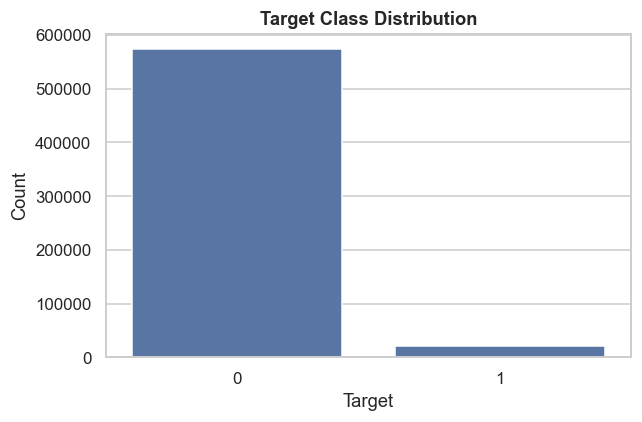

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The target variable is strongly imbalanced. The positive class represents
only approximately 3.6% of the observations. Therefore, accuracy alone may
not be an appropriate evaluation metric for the later classification models.

### 5. Numerical Feature Analysis:

Descriptive Statistics:

In [11]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ps_ind_01,595212.0,1.900378,1.983789,0.000000,0.000000,1.000000,3.000000,7.000000
ps_ind_03,595212.0,4.423318,2.699902,0.000000,2.000000,4.000000,6.000000,11.000000
ps_ind_14,595212.0,0.012451,0.127545,0.000000,0.000000,0.000000,0.000000,4.000000
ps_ind_15,595212.0,7.299922,3.546042,0.000000,5.000000,7.000000,10.000000,13.000000
ps_reg_01,595212.0,0.610991,0.287643,0.000000,0.400000,0.700000,0.900000,0.900000
ps_reg_02,595212.0,0.439184,0.404264,0.000000,0.200000,0.300000,0.600000,1.800000
ps_reg_03,487440.0,0.894047,0.345413,0.061237,0.633443,0.801561,1.083974,4.037945
ps_car_11,595207.0,2.346100,0.832495,0.000000,2.000000,3.000000,3.000000,3.000000
ps_car_12,595211.0,0.379947,0.058300,0.100000,0.316228,0.374166,0.400000,1.264911
ps_car_13,595212.0,0.813265,0.224588,0.250619,0.670867,0.765811,0.906190,3.720626


Identify numeric features with few distinct values so they can be displayed as discrete bar charts rather than continuous histograms:

In [12]:
df[numeric_cols].nunique().sort_values()

ps_car_11         4
ps_ind_14         5
ps_calc_04        6
ps_calc_05        7
ps_ind_01         8
ps_calc_09        8
ps_calc_07       10
ps_calc_03       10
ps_calc_02       10
ps_calc_01       10
ps_reg_01        10
ps_calc_06       11
ps_calc_08       11
ps_calc_12       11
ps_ind_03        12
ps_calc_13       14
ps_ind_15        14
ps_car_15        15
ps_reg_02        19
ps_calc_11       20
ps_calc_14       24
ps_calc_10       26
ps_car_12       183
ps_car_14       849
ps_reg_03      5012
ps_car_13     70482
dtype: int64

This distinction is used only for visualization:

In [13]:
discrete_cols = [c for c in numeric_cols if df[c].nunique() <= 30]
continuous_cols = [c for c in numeric_cols if df[c].nunique() > 30]

print(f"discrete   ({len(discrete_cols):2d}) : {discrete_cols}")
print("")
print(f"continuous ({len(continuous_cols):2d}) : {continuous_cols}")

discrete   (22) : ['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_car_11', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']

continuous ( 4) : ['ps_reg_03', 'ps_car_12', 'ps_car_13', 'ps_car_14']


__Numerical Feature Distributions:__

In [14]:
calc_num  = [c for c in numeric_cols if c.startswith("ps_calc")]
other_num = [c for c in numeric_cols if not c.startswith("ps_calc")]

num_data = df[numeric_cols]   # NaN kept as-is: seaborn skips them

DISCRETE_MAX = 30

def is_discrete(col):
    return num_data[col].nunique() <= DISCRETE_MAX


def discrete_bins(col):
    # One bin centred on each observed value. Works for integer steps
    # (ps_ind_15) and fractional ones (ps_calc_02 steps by 0.1) alike.
    u = np.sort(num_data[col].dropna().unique())
    if len(u) < 2:
        return 10
    step = np.diff(u).min()
    if (u[-1] - u[0]) / step > 200:      # irregular spacing -> fall back
        return 40
    return np.arange(u[0] - step / 2, u[-1] + step, step)

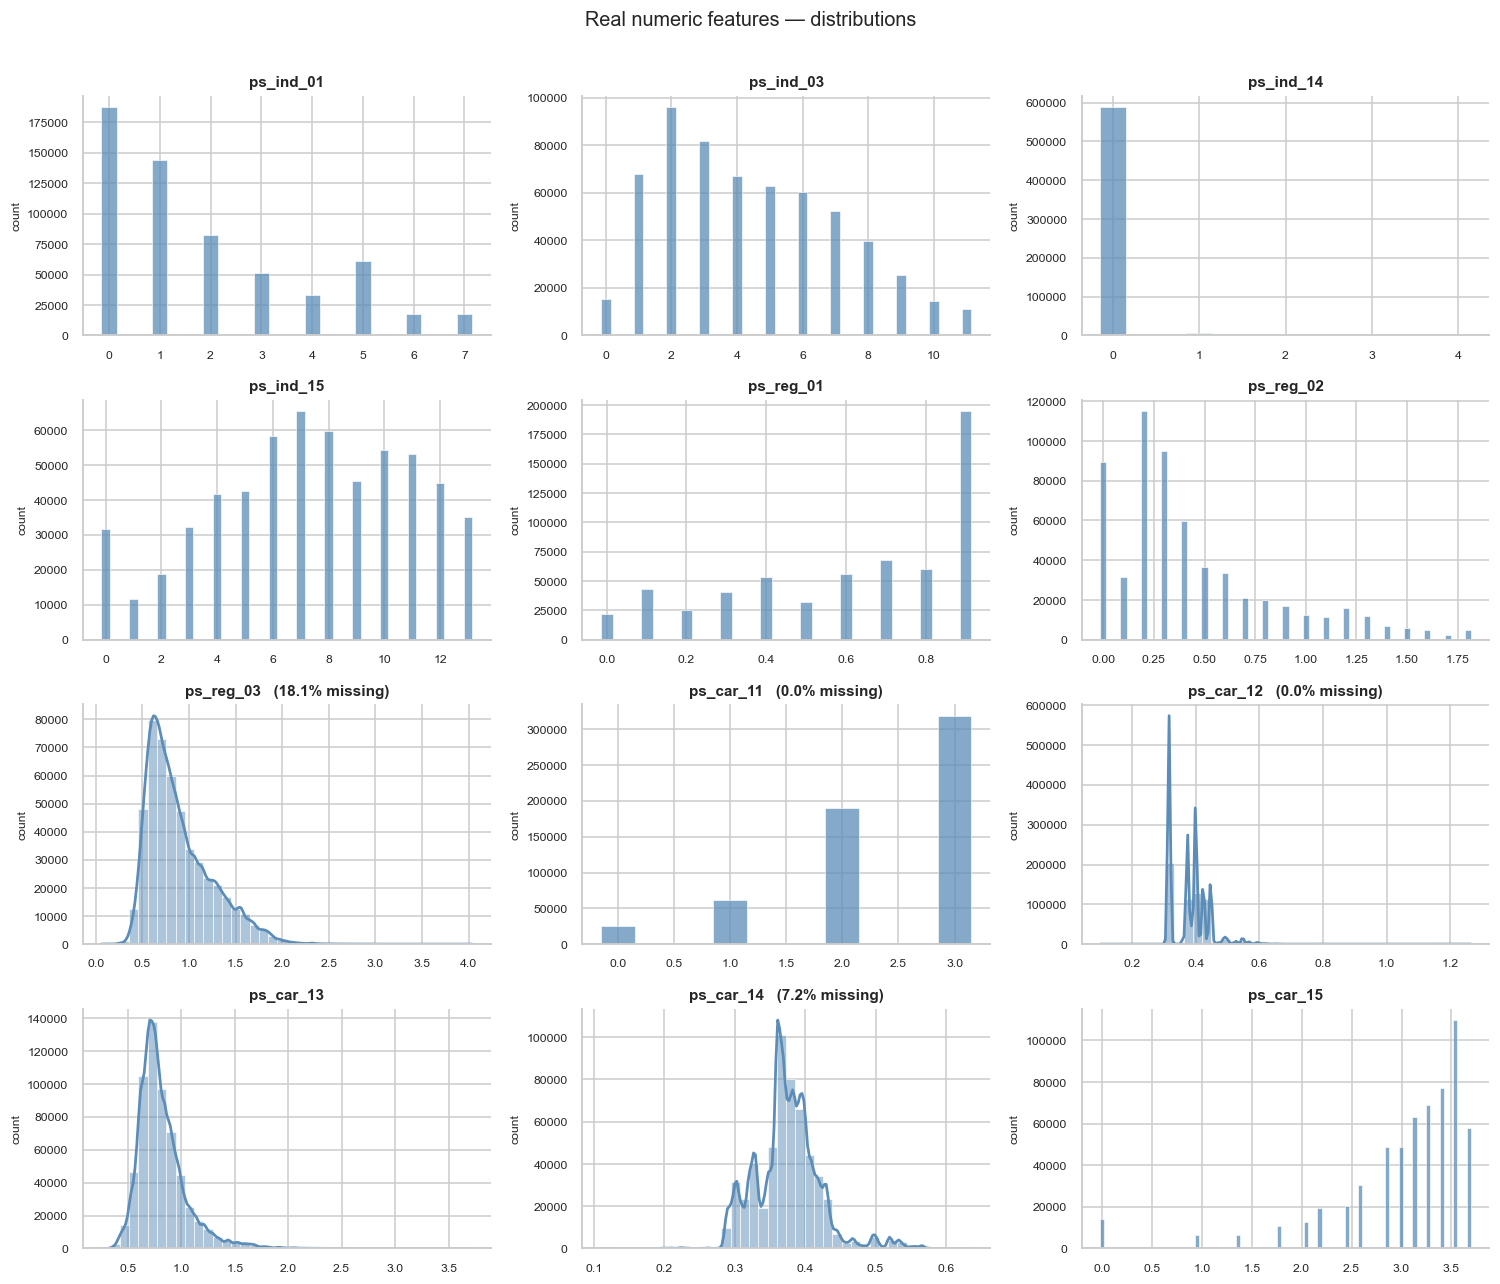

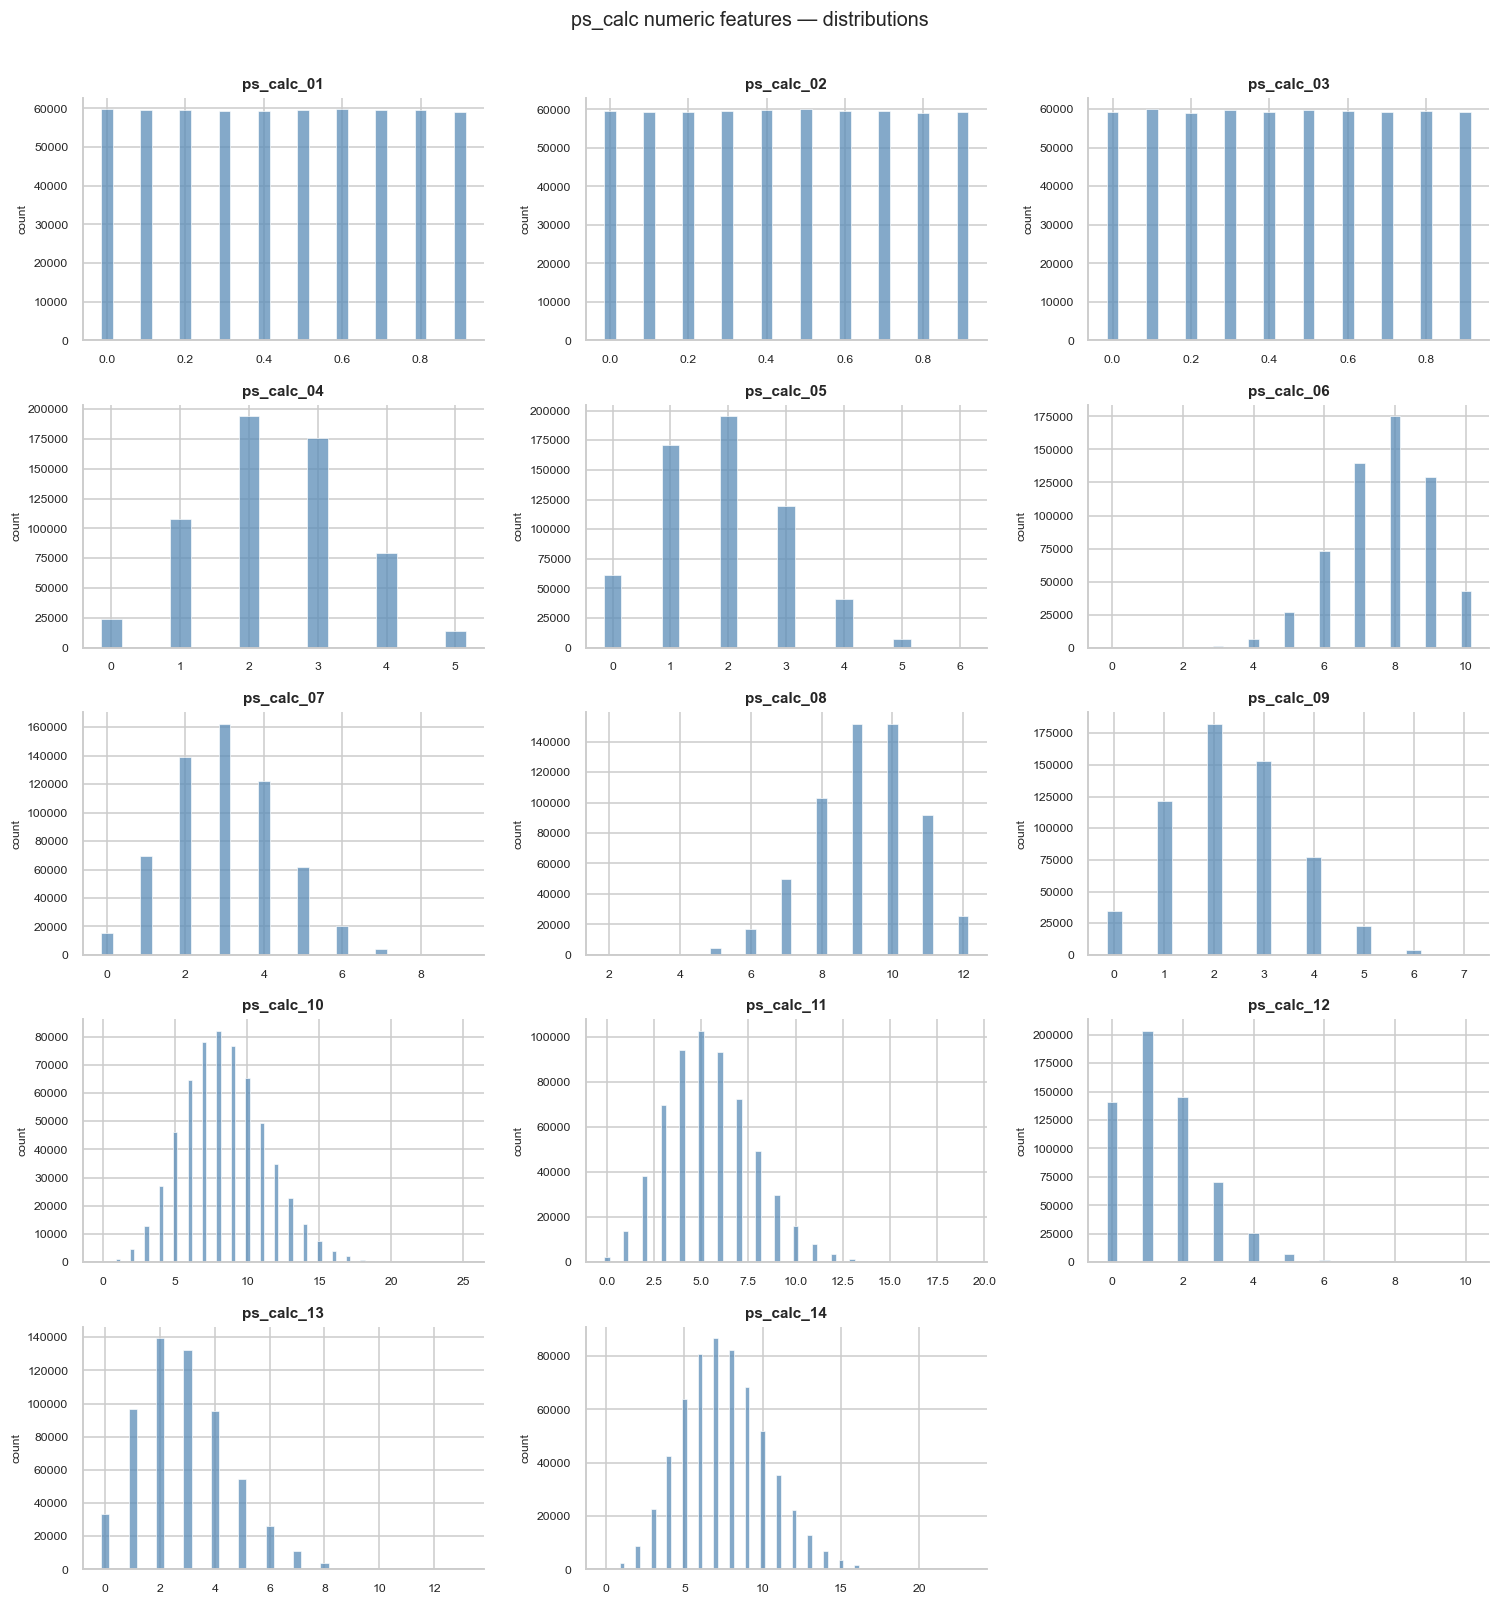

In [15]:
def plot_distributions(cols, title, ncols=3, height=2.9, shrink=0.3):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, height * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        disc = is_discrete(col)
        sns.histplot(
            data=num_data, x=col, ax=ax,
            bins=discrete_bins(col) if disc else 40,
            kde=not disc,
            shrink=shrink if disc else 1.0,   # <- the only change: thinner bars
            color="#5b8db8",
            edgecolor="white", linewidth=0.4,
            line_kws={"lw": 1.8, "color": "#1f4e79"},
        )
        n_miss = df[col].isna().mean() * 100
        ax.set_title(col + (f"   ({n_miss:.1f}% missing)" if n_miss > 0 else ""),
                     fontsize=10, pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("count", fontsize=8)
        ax.tick_params(labelsize=8)
        ax.ticklabel_format(axis="y", style="plain")
        sns.despine(ax=ax)

    for ax in axes[len(cols):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=13, y=1.005)
    fig.tight_layout()
    plt.show()


plot_distributions(other_num, "Real numeric features — distributions")
plot_distributions(calc_num,  "ps_calc numeric features — distributions")

 __Numerical features vs. target:__

In [16]:
target_col = "target"

/var/folders/5z/m2zgxpqx5zqbsxb6_rmb_c2c0000gn/T/ipykernel_48800/4016395884.py:41: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.tight_layout(rect=[0, 0, 1, 0.97])
/Users/leyla.louache/Documents/Uni/advanced-data-analytics/ADA/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


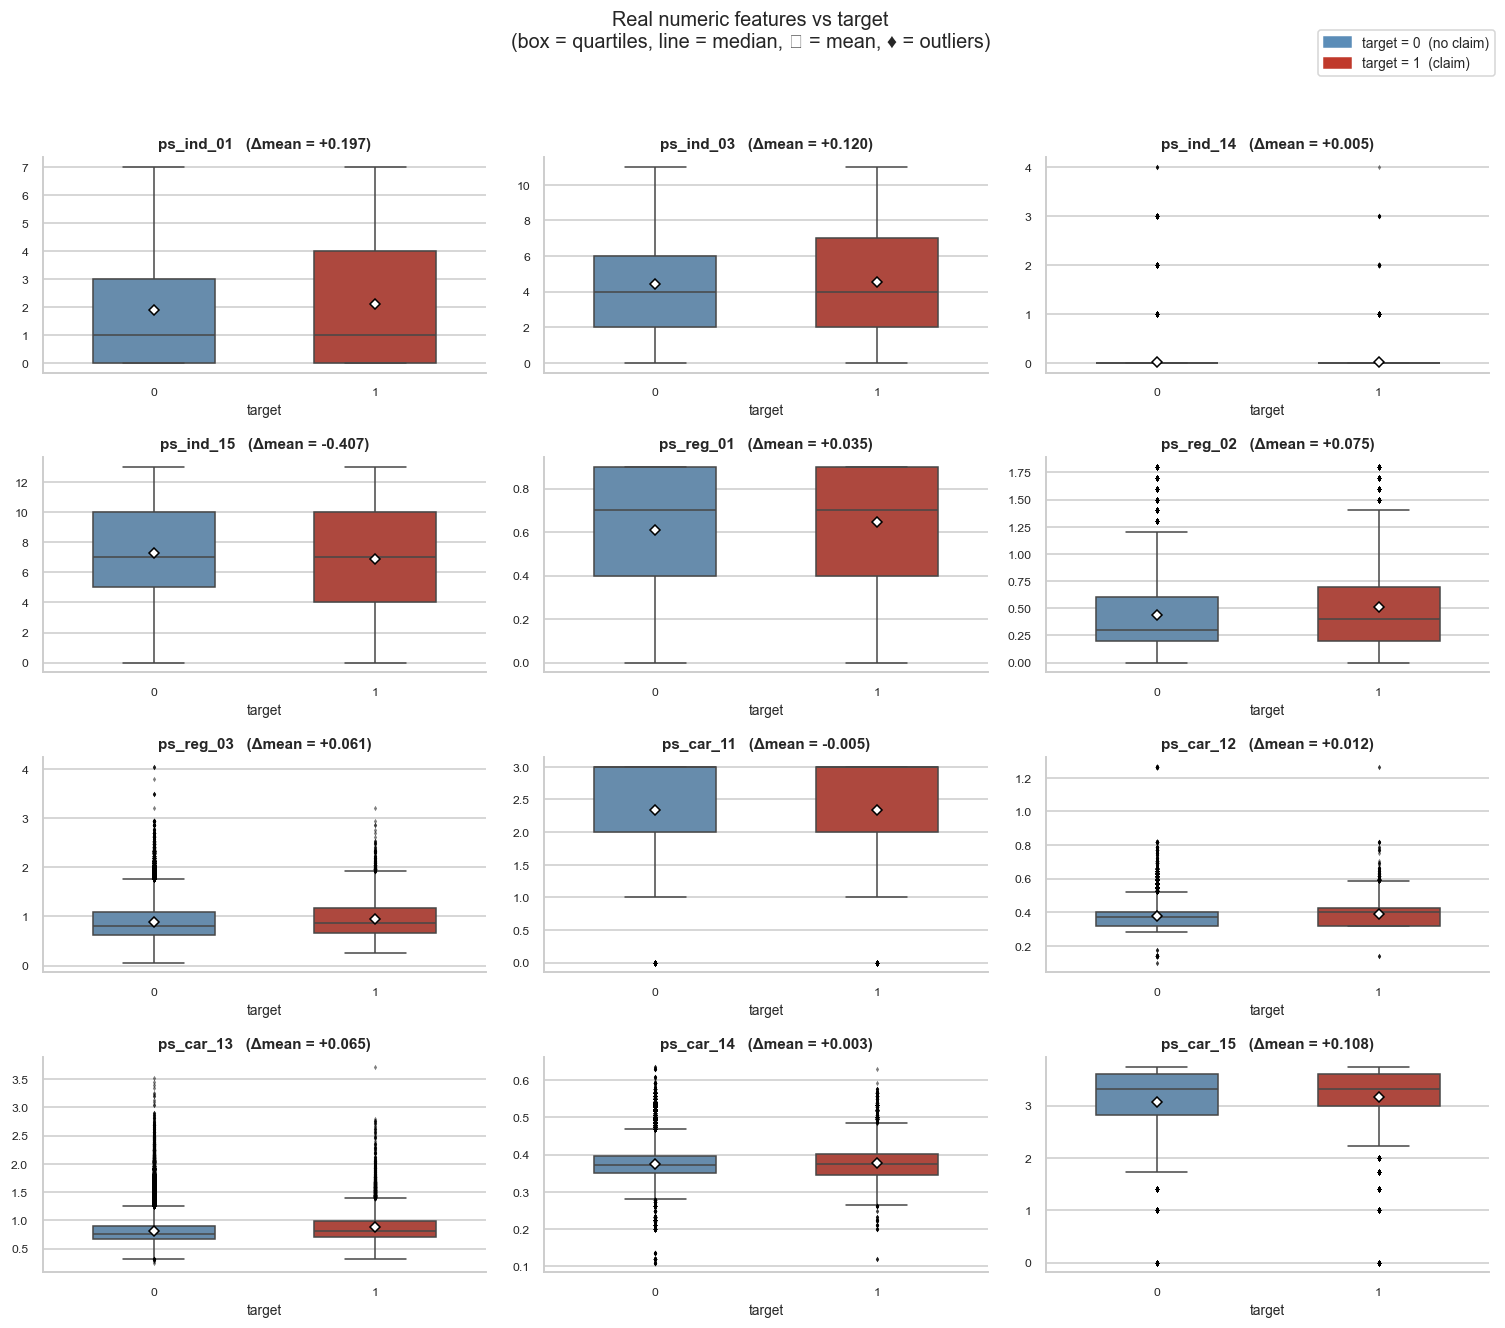

/var/folders/5z/m2zgxpqx5zqbsxb6_rmb_c2c0000gn/T/ipykernel_48800/4016395884.py:41: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.tight_layout(rect=[0, 0, 1, 0.97])
/Users/leyla.louache/Documents/Uni/advanced-data-analytics/ADA/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


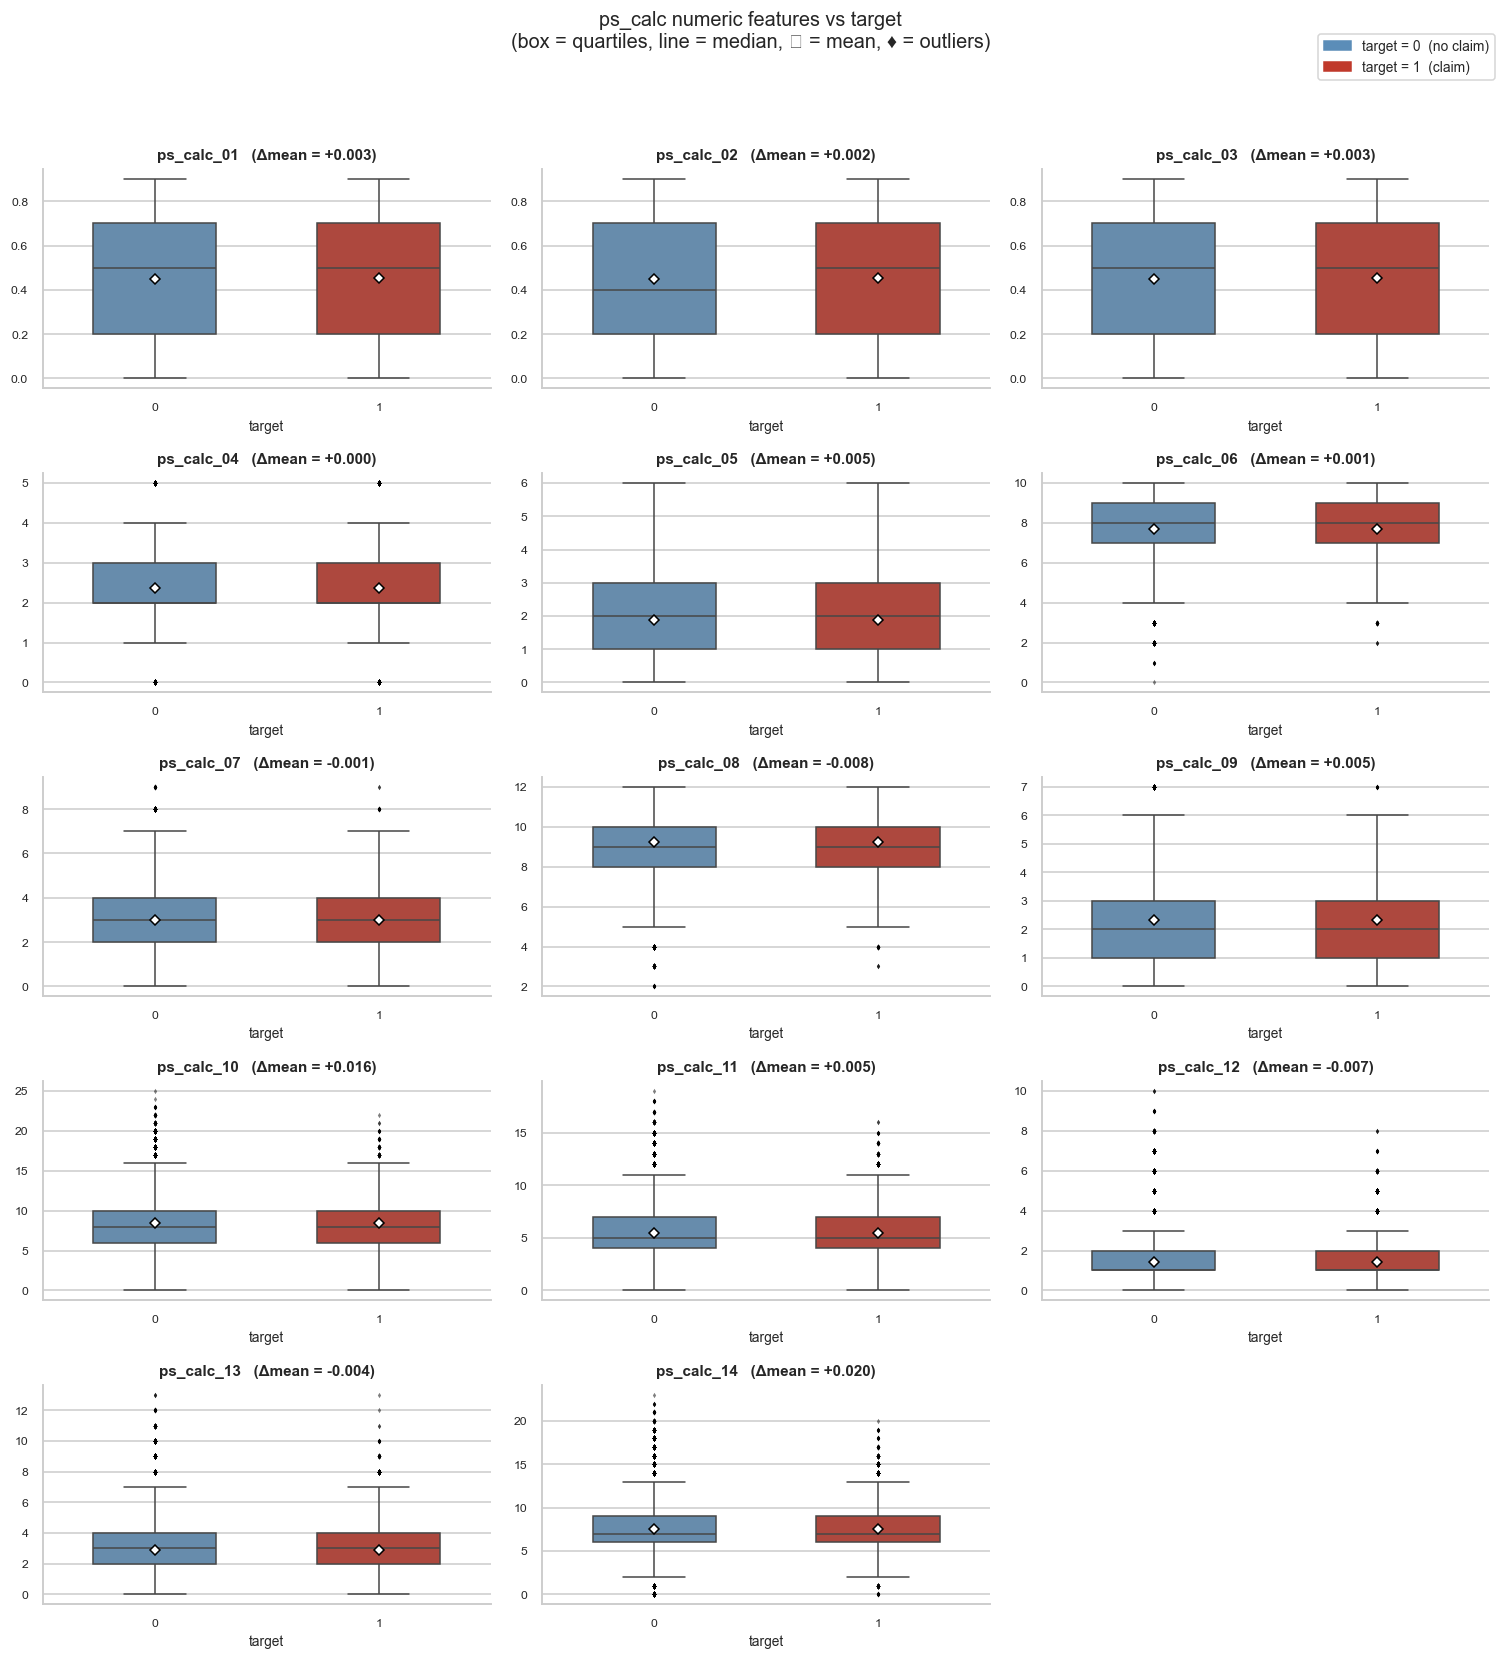

In [17]:
def plot_box_by_target(cols, title, ncols=3, height=3.0):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, height * nrows))
    axes = np.array(axes).reshape(-1)

    plot_df = num_data.copy()
    plot_df["target"] = pd.to_numeric(df[target_col]).astype(int).values

    for ax, col in zip(axes, cols):
        sns.boxplot(
            data=plot_df, x="target", y=col, ax=ax,
            hue="target", legend=False,       # no per-subplot legend
            palette=PALETTE,
            width=0.55,
            showfliers=True,                  # <- outliers back on
            flierprops={"marker": "d", "markersize": 2.5,
                        "markerfacecolor": "black", "markeredgecolor": "none",
                        "alpha": 0.5},
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white",
                       "markeredgecolor": "black", "markersize": 5},
        )
        m = plot_df.groupby("target")[col].mean()
        ax.set_title(f"{col}   (Δmean = {m[1] - m[0]:+.3f})", fontsize=10, pad=6)
        ax.set_xlabel("target", fontsize=9)
        ax.set_ylabel("")
        ax.tick_params(labelsize=8)
        sns.despine(ax=ax)

    for ax in axes[len(cols):]:
        ax.axis("off")

    # One shared legend for the whole figure.
    handles = [mpatches.Patch(color=PALETTE[0], label="target = 0  (no claim)"),
               mpatches.Patch(color=PALETTE[1], label="target = 1  (claim)")]
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.995, 0.995),
               frameon=True, fontsize=9)

    fig.suptitle(title + "\n(box = quartiles, line = median, ◇ = mean, ♦ = outliers)",
                 fontsize=13, y=1.005)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_box_by_target(other_num, "Real numeric features vs target")
plot_box_by_target(calc_num,  "ps_calc numeric features vs target")

__Correlation between numerical features:__

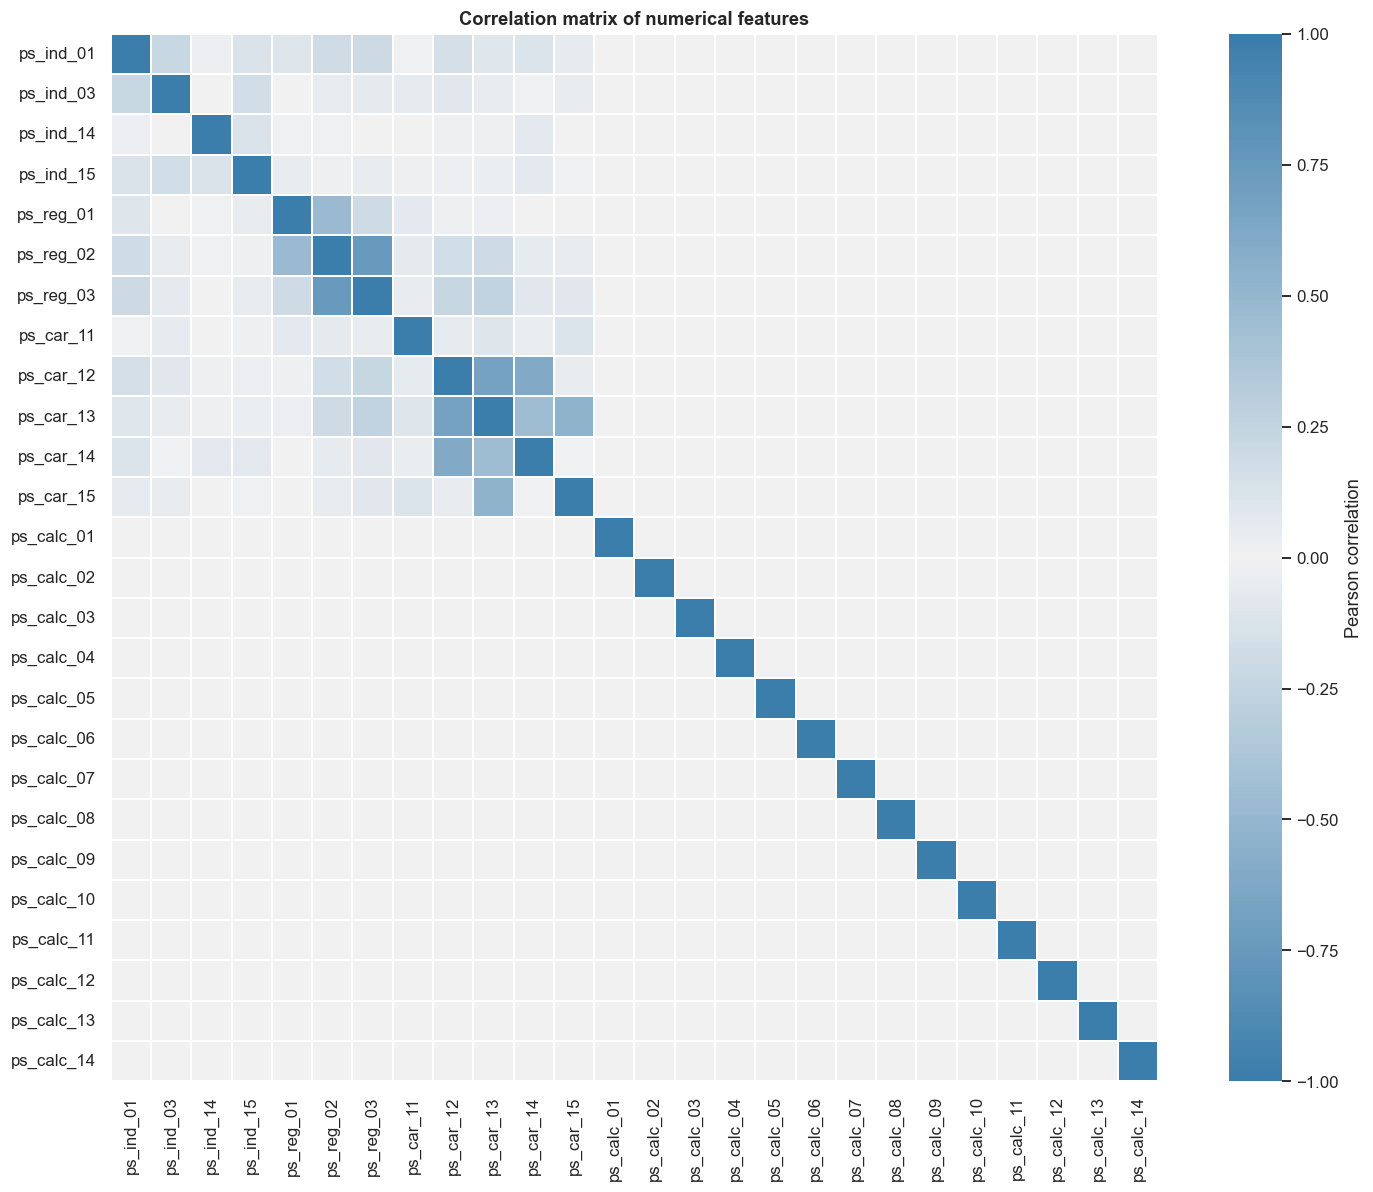

In [18]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
cmap = sns.diverging_palette(240, 240, s=80, l=50, as_cmap=True)
sns.heatmap(
    corr,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Correlation matrix of numerical features")
plt.tight_layout()

plt.savefig(
    FIGDIR / "03_numerical_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

__Close-up on non calc features :__ 

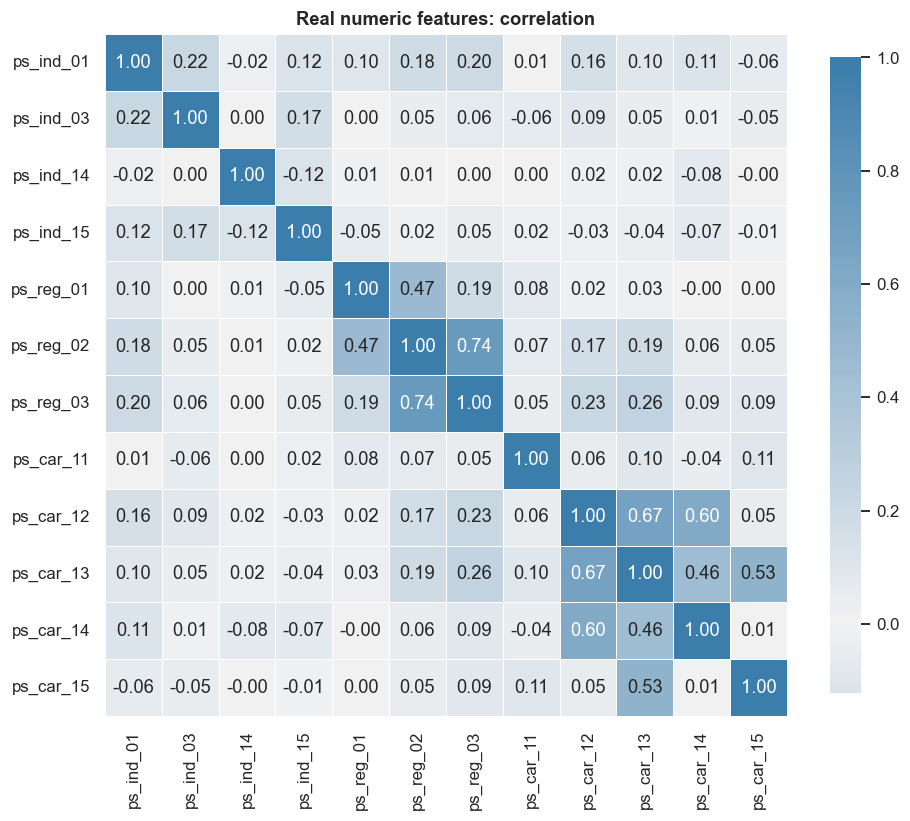

In [19]:
correlations = num_data[other_num].corr()

###cmap = sns.diverging_palette(50, 10, as_cmap=True)
cmap = sns.diverging_palette(240, 240, s=80, l=50, as_cmap=True)
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(correlations, cmap=cmap, vmax=1.0, center=0, fmt='.2f',
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .75})
plt.title("Real numeric features: correlation")
plt.show()

In [20]:
mask = np.triu(np.ones_like(correlations, dtype=bool))
pairs = correlations.where(~mask).stack().reset_index()
pairs.columns = ["f1", "f2", "corr"]
print(pairs.reindex(pairs["corr"].abs().sort_values(ascending=False).index).head(8).round(3))

            f1         f2   corr
77   ps_reg_03  ps_reg_02  0.743
116  ps_car_13  ps_car_12  0.672
128  ps_car_14  ps_car_12  0.603
141  ps_car_15  ps_car_13  0.530
64   ps_reg_02  ps_reg_01  0.471
129  ps_car_14  ps_car_13  0.459
114  ps_car_13  ps_reg_03  0.265
102  ps_car_12  ps_reg_03  0.229


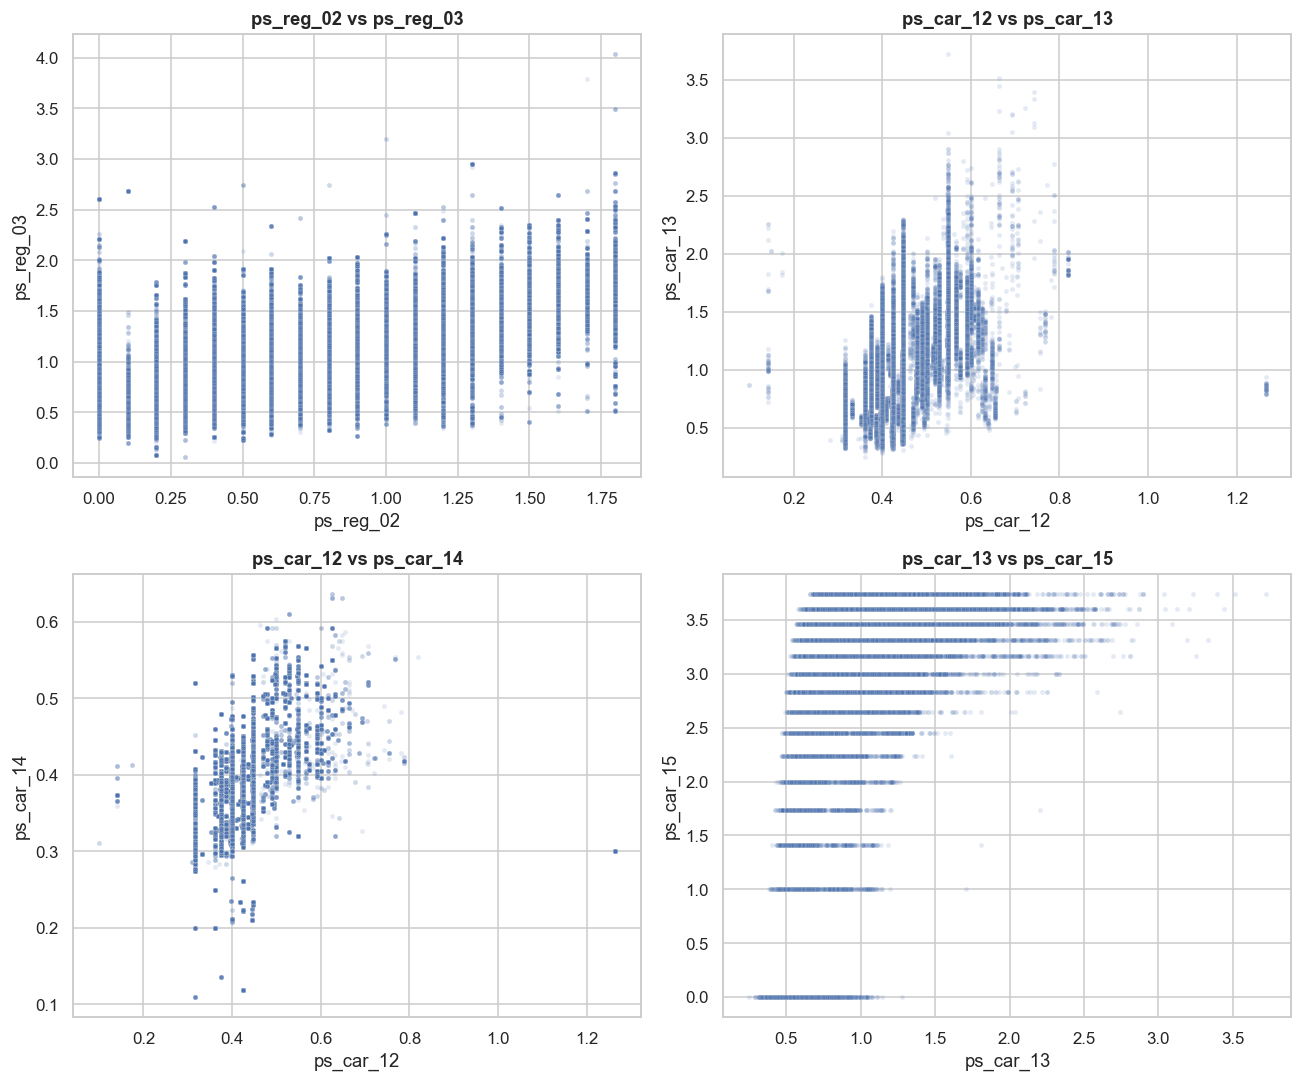

In [21]:
pairs = [
    ("ps_reg_02", "ps_reg_03"),
    ("ps_car_12", "ps_car_13"),
    ("ps_car_12", "ps_car_14"),
    ("ps_car_13", "ps_car_15"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (x, y) in zip(axes.flat, pairs):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        alpha=0.15,
        s=10,
        ax=ax
    )
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

#### Correlation with the target:

In [58]:
y_num = pd.to_numeric(df[TARGET]).astype(int)

target_corr = num_data.corrwith(y_num).abs().sort_values(ascending=False)
print(target_corr.round(5))

ps_car_13     0.05390
ps_car_12     0.03880
ps_reg_02     0.03480
ps_reg_03     0.03376
ps_car_15     0.02767
ps_reg_01     0.02289
ps_ind_15     0.02151
ps_ind_01     0.01857
ps_car_14     0.01167
ps_ind_03     0.00836
ps_ind_14     0.00744
ps_calc_03    0.00191
ps_calc_01    0.00178
ps_calc_14    0.00136
ps_calc_02    0.00136
ps_car_11     0.00122
ps_calc_12    0.00113
ps_calc_10    0.00106
ps_calc_08    0.00101
ps_calc_05    0.00077
ps_calc_09    0.00072
ps_calc_13    0.00045
ps_calc_11    0.00037
ps_calc_07    0.00010
ps_calc_06    0.00008
ps_calc_04    0.00003
dtype: float64


The strongest correlation with the target reaches only 0.054 (ps_car_13), and all 14
numeric ps_calc features fall below 0.002 on 595,000 rows. No numeric feature separates
the classes on its own, which favours models able to capture interactions.

### 6. Categorical Feature Analysis:

__Number of Categories per Feature:__

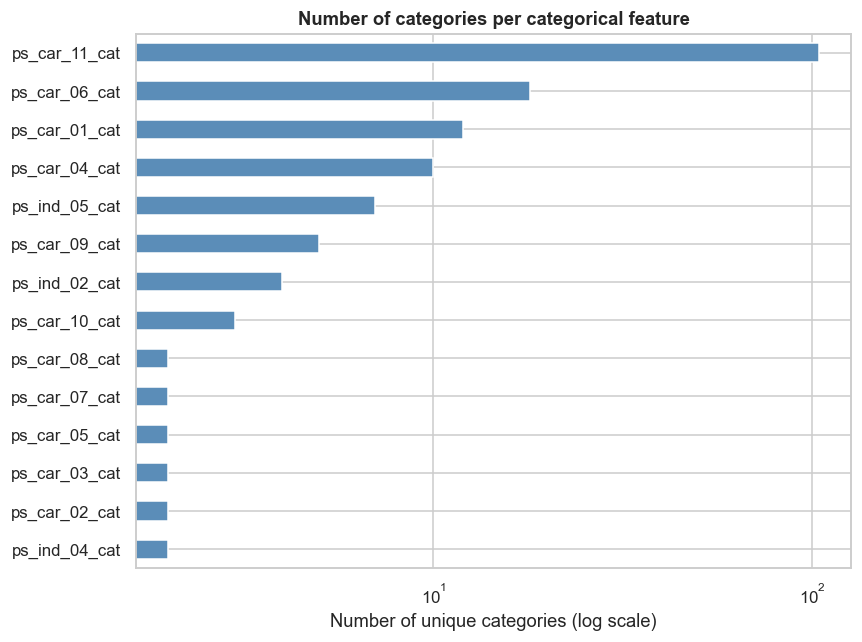

In [22]:
ax = (
    df[categorical_cols]
    .nunique()
    .sort_values()
    .plot(kind="barh", figsize=(8, 6), color=PALETTE[0])
)
ax.set_xscale("log")
plt.xlabel("Number of unique categories (log scale)")
plt.ylabel("")
plt.title("Number of categories per categorical feature")
plt.tight_layout()
plt.show()

__Number of missing values:__

In [23]:
display(
    meta.loc[
        (meta["feature_type"] == "categorical") & (meta["n_missing"] > 0),
        ["feature", "n_missing", "missing_pct"]
    ].sort_values("missing_pct", ascending=False)
)

,feature,n_missing,missing_pct
24,ps_car_03_cat,411231,69.089837
26,ps_car_05_cat,266551,44.782531
28,ps_car_07_cat,11489,1.930237
5,ps_ind_05_cat,5809,0.975955
30,ps_car_09_cat,569,0.095596
2,ps_ind_02_cat,216,0.036290
22,ps_car_01_cat,107,0.017977
4,ps_ind_04_cat,83,0.013945
23,ps_car_02_cat,5,0.000840


__Claim rate by level :__

In [24]:
for c in df.columns:
    if str(df[c].dtype) == "category":
        df[c] = pd.to_numeric(df[c].astype(str), errors="coerce")

df[TARGET] = df[TARGET].astype(int)
print(df.dtypes.value_counts())   # no 'category' left

float64    35
int64      23
Name: count, dtype: int64


plotted separately: ['ps_car_11_cat']


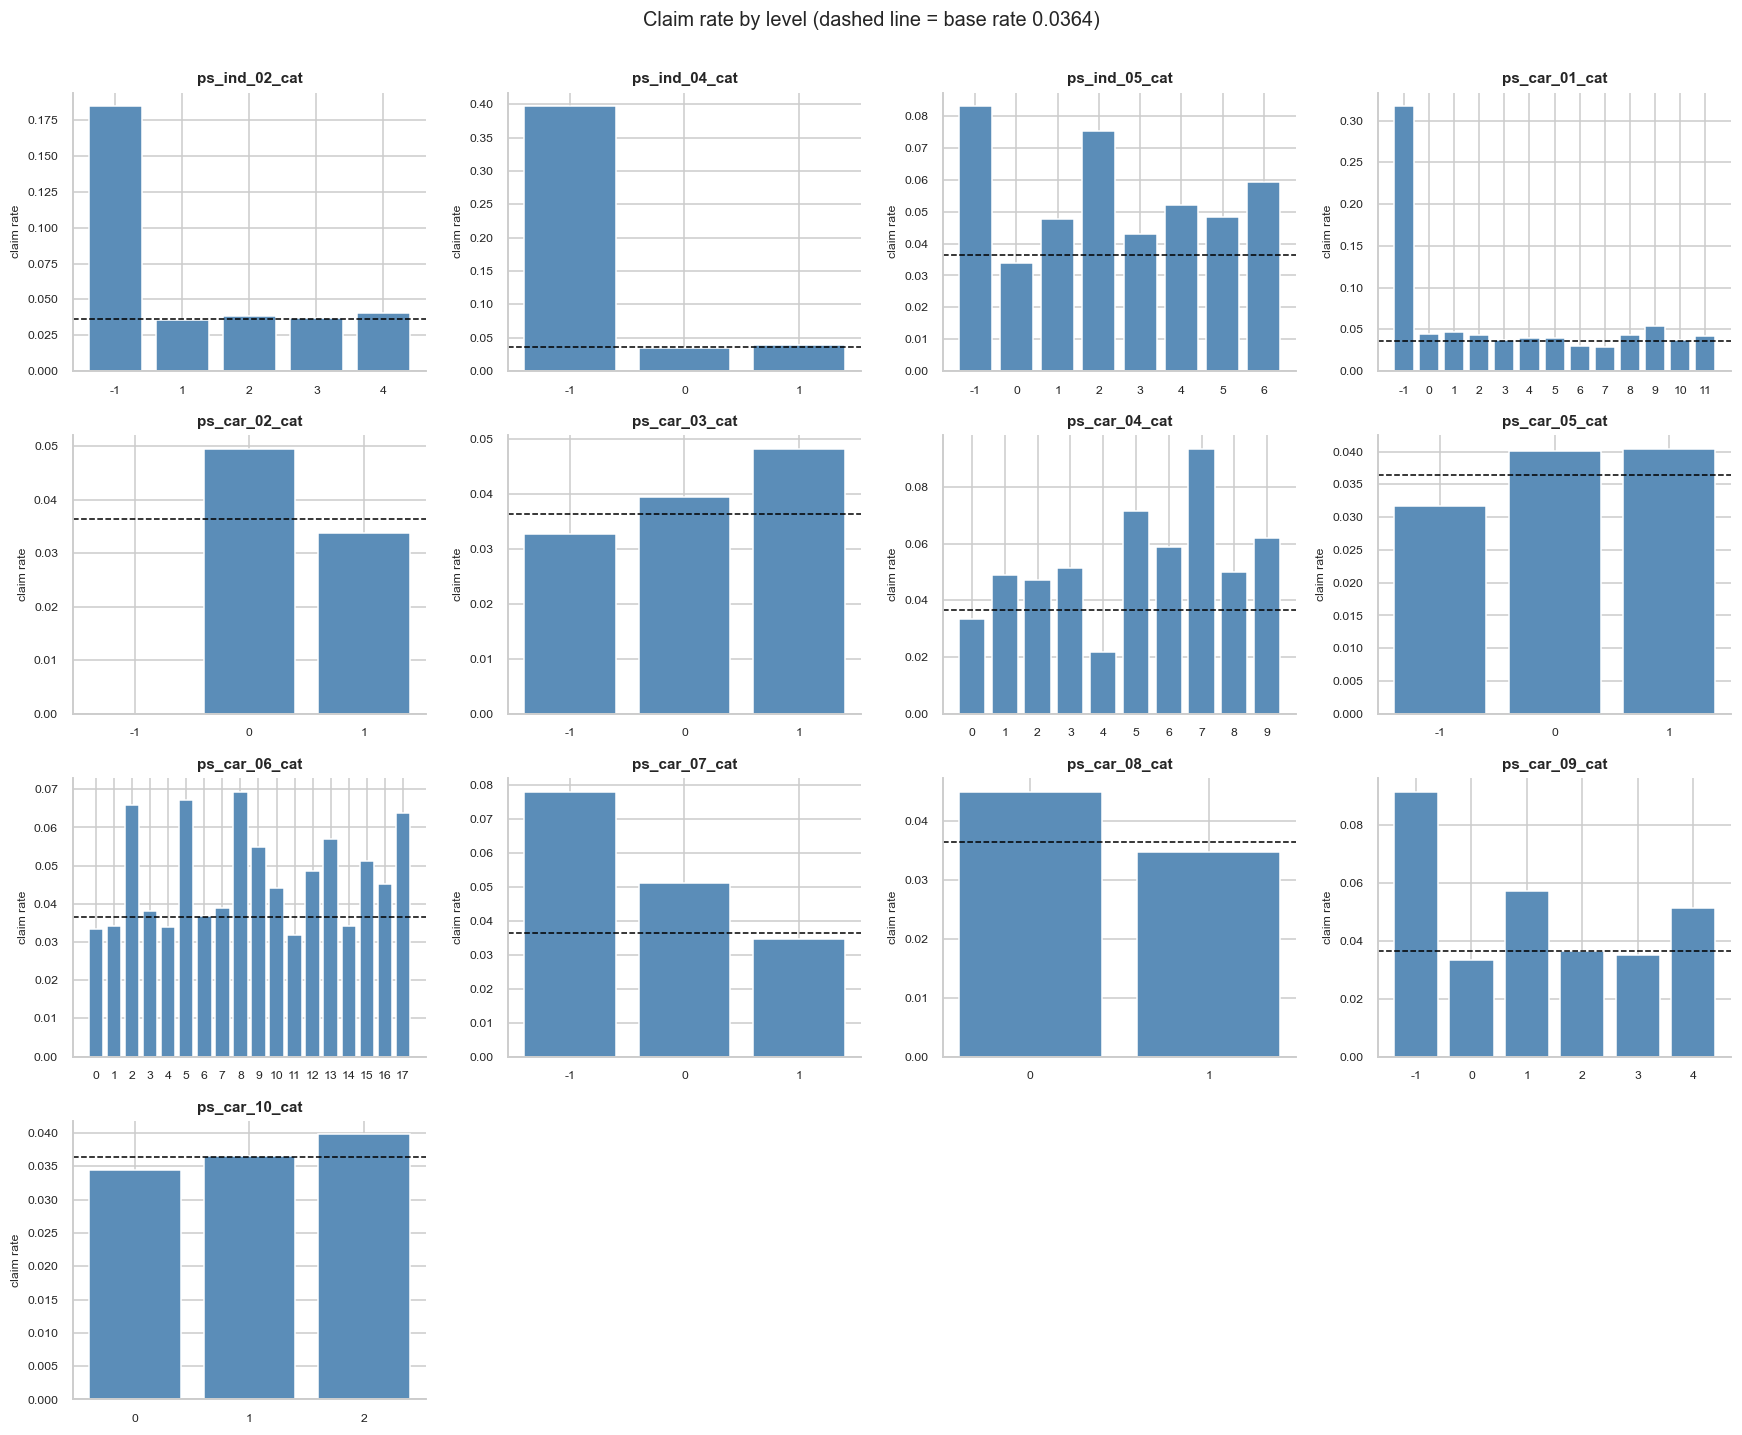

In [25]:
df_cat = df[categorical_cols].apply(pd.to_numeric, errors="coerce").fillna(-1).astype(int)
base_rate = df[TARGET].mean()

small_cats = [c for c in categorical_cols if df[c].nunique() <= 20]
big_cats   = [c for c in categorical_cols if df[c].nunique() > 20]
print("plotted separately:", big_cats)

nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 13))
axes = axes.flatten()

for ax, col in zip(axes, small_cats):
    rates = df[TARGET].groupby(df_cat[col]).mean()
    ax.bar(rates.index.astype(str), rates.values, color=PALETTE[0])
    ax.axhline(base_rate, color="black", ls="--", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("claim rate", fontsize=8)
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)

for ax in axes[len(small_cats):]:
    ax.set_visible(False)

fig.suptitle(f"Claim rate by level (dashed line = base rate {base_rate:.4f})",
             fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

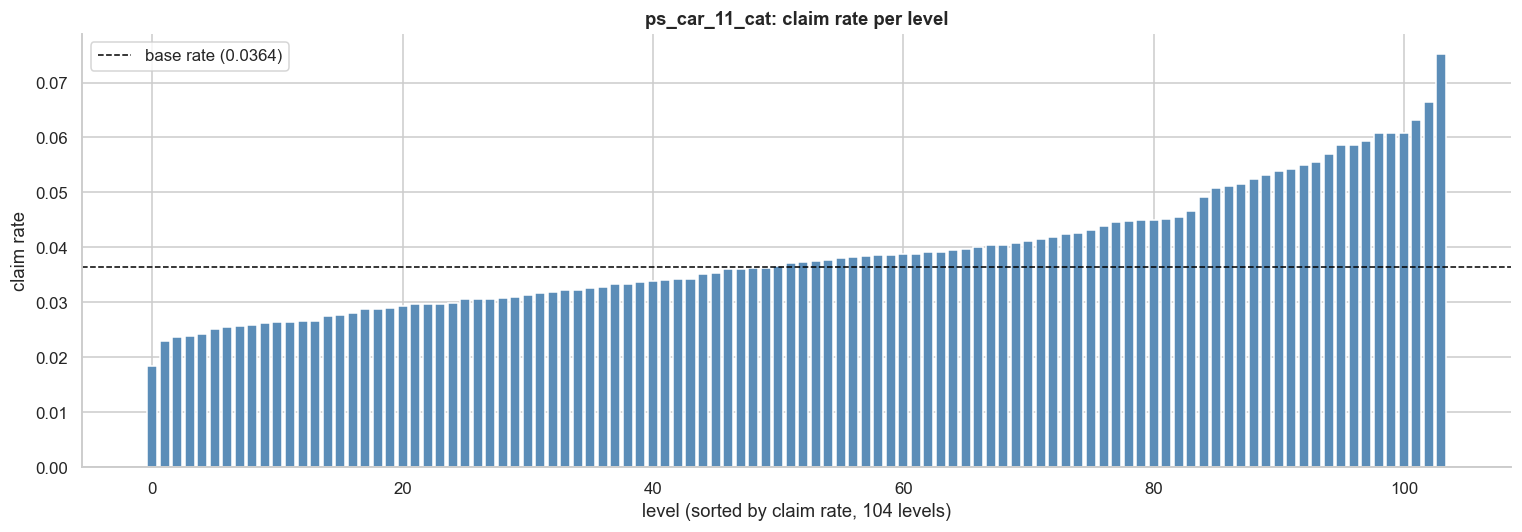

In [26]:
grp = df[TARGET].groupby(df_cat["ps_car_11_cat"]).agg(n="size", rate="mean")
grp = grp.sort_values("rate")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(grp)), grp["rate"], color=PALETTE[0])
ax.axhline(base_rate, color="black", ls="--", lw=1,
           label=f"base rate ({base_rate:.4f})")
ax.set_xlabel(f"level (sorted by claim rate, {len(grp)} levels)")
ax.set_ylabel("claim rate")
ax.set_title("ps_car_11_cat: claim rate per level")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

#### __Association with the target :__

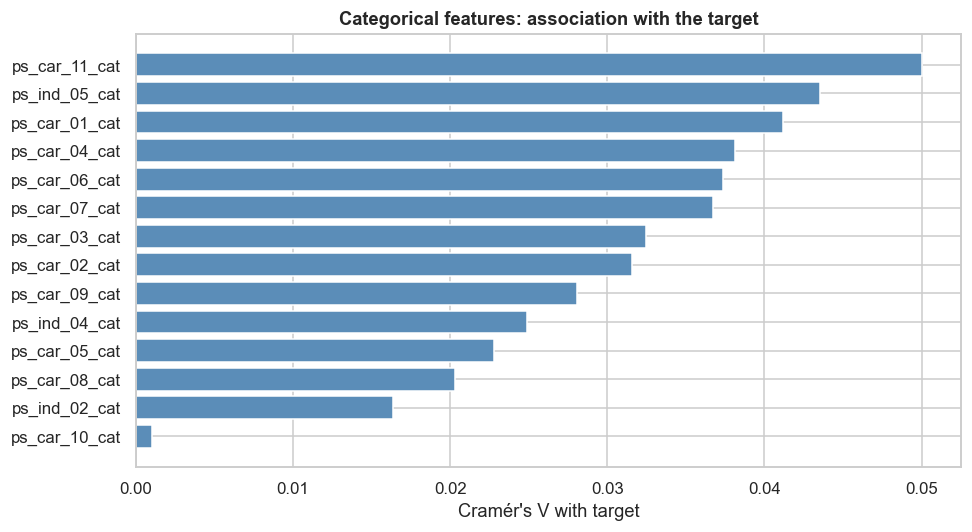

ps_car_11_cat    0.0500
ps_ind_05_cat    0.0435
ps_car_01_cat    0.0412
ps_car_04_cat    0.0382
ps_car_06_cat    0.0374
ps_car_07_cat    0.0367
ps_car_03_cat    0.0324
ps_car_02_cat    0.0315
ps_car_09_cat    0.0281
ps_ind_04_cat    0.0249
ps_car_05_cat    0.0228
ps_car_08_cat    0.0203
ps_ind_02_cat    0.0164
ps_car_10_cat    0.0010
dtype: float64


In [27]:
def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

y_num = pd.to_numeric(df[TARGET]).astype(int)
cv = pd.Series({c: cramers_v(df_cat[c], y_num) for c in categorical_cols}).sort_values()

plt.figure(figsize=(9, 5))
plt.barh(cv.index, cv.values, color=PALETTE[0])
plt.xlabel("Cramér's V with target")
plt.title("Categorical features: association with the target")
plt.tight_layout()
plt.show()

print(cv.sort_values(ascending=False).round(4))

The car family occupies eight of the top ten positions, consistent with the numeric analysis.

### 7. Binary Feature Analysis:

__Binary Feature Distributions:__

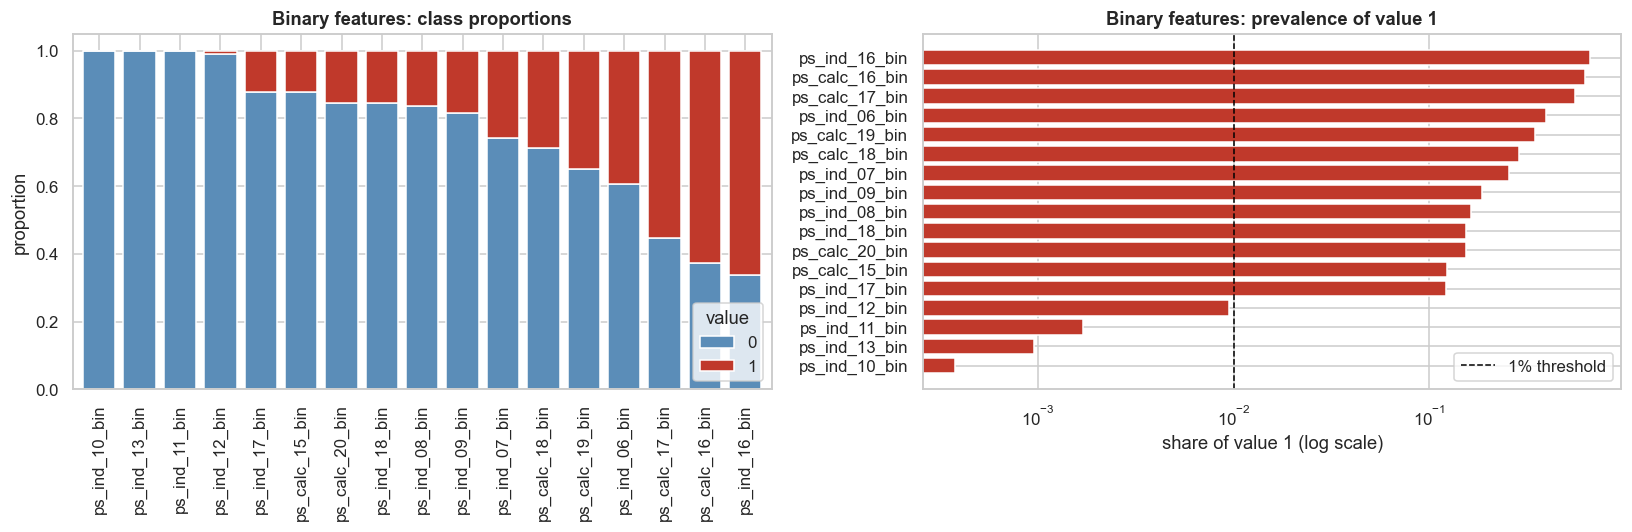

ps_ind_10_bin     0.000373
ps_ind_13_bin     0.000948
ps_ind_11_bin     0.001692
ps_ind_12_bin     0.009439
ps_ind_17_bin     0.121081
ps_calc_15_bin    0.122427
ps_calc_20_bin    0.153318
ps_ind_18_bin     0.153446
ps_ind_08_bin     0.163921
ps_ind_09_bin     0.185304
ps_ind_07_bin     0.257033
ps_calc_18_bin    0.287182
ps_calc_19_bin    0.349024
ps_ind_06_bin     0.393742
ps_calc_17_bin    0.554182
ps_calc_16_bin    0.627840
ps_ind_16_bin     0.660823
dtype: float64

In [28]:
bin_num = df[binary_cols].astype("int8")
prevalence = bin_num.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: how each feature splits between its two classes.
prop = pd.DataFrame({0: 1 - prevalence, 1: prevalence})
prop.plot(kind="bar", stacked=True, ax=axes[0],
          color=[PALETTE[0], PALETTE[1]], width=0.8)
axes[0].set_ylabel("proportion")
axes[0].set_title("Binary features: class proportions")
axes[0].legend(title="value", loc="lower right")

# Right: share of 1s only, log scale so rare features stay readable.
axes[1].barh(prevalence.index, prevalence.values, color=PALETTE[1])
axes[1].set_xscale("log")
axes[1].axvline(0.01, color="black", ls="--", lw=1, label="1% threshold")
axes[1].set_xlabel("share of value 1 (log scale)")
axes[1].set_title("Binary features: prevalence of value 1")
axes[1].legend()

plt.tight_layout()
plt.show()

prevalence.round(6)

__Binary features vs target__

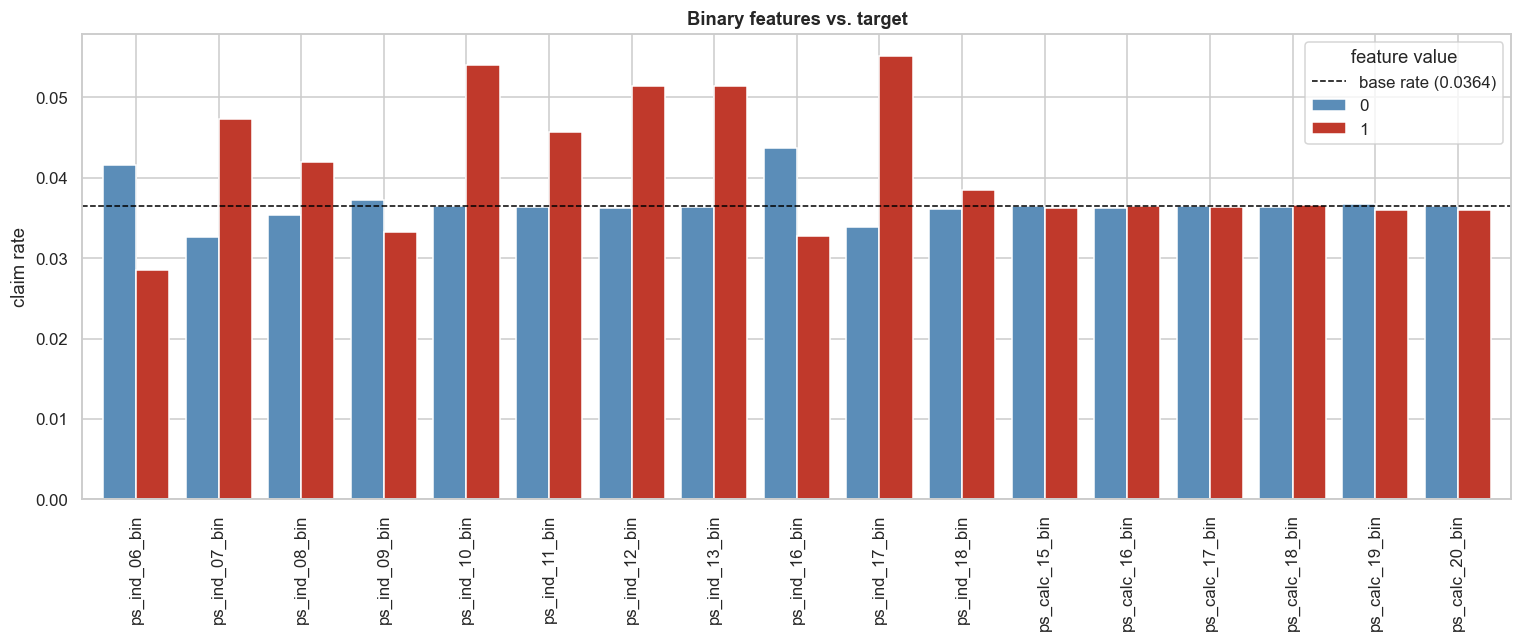

,0,1,n_1,gap,lift
ps_ind_17_bin,0.0339,0.0552,72069,0.0213,1.5133
ps_ind_10_bin,0.0364,0.0541,222,0.0176,1.4831
ps_ind_12_bin,0.0363,0.0514,5618,0.0151,1.4114
ps_ind_13_bin,0.0364,0.0514,564,0.0150,1.4108
ps_ind_07_bin,0.0327,0.0473,152989,0.0147,1.2991
ps_ind_06_bin,0.0416,0.0285,234360,-0.0130,0.7830
ps_ind_16_bin,0.0437,0.0327,393330,-0.0110,0.8977
ps_ind_11_bin,0.0364,0.0457,1007,0.0092,1.2533
ps_ind_08_bin,0.0354,0.0420,97568,0.0067,1.1527
ps_ind_09_bin,0.0372,0.0332,110295,-0.0040,0.9112


In [29]:
base_rate = df[TARGET].mean()

rates = pd.DataFrame({
    0: [df.loc[bin_num[col] == 0, TARGET].mean() for col in binary_cols],
    1: [df.loc[bin_num[col] == 1, TARGET].mean() for col in binary_cols]
}, index=binary_cols)

rates["n_1"] = [(bin_num[col] == 1).sum() for col in binary_cols]

fig, ax = plt.subplots(figsize=(14, 6))
rates[[0, 1]].plot(kind="bar", ax=ax, width=0.8,
                   color=[PALETTE[0], PALETTE[1]])
ax.axhline(base_rate, color="black", ls="--", lw=1,
           label=f"base rate ({base_rate:.4f})")
ax.set_ylabel("claim rate")
ax.set_xlabel("")
ax.set_title("Binary features vs. target")
ax.legend(title="feature value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

rates["gap"] = rates[1] - rates[0]
rates["lift"] = rates[1] / base_rate
rates.reindex(rates["gap"].abs().sort_values(ascending=False).index).round(4)

#### __Association with the target across all features :__

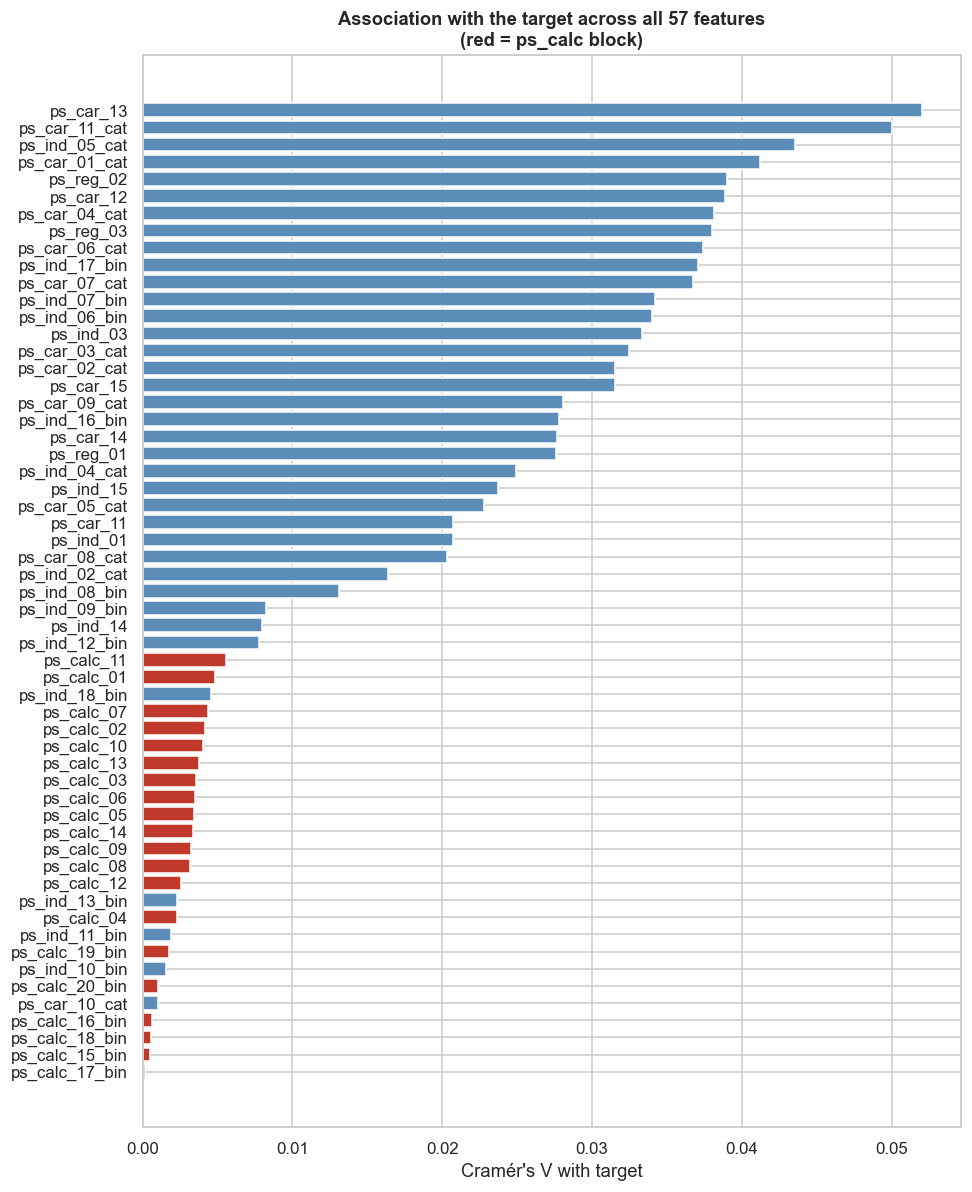

ps_calc  — mean V: 0.0028 | max: 0.0055
others   — mean V: 0.0259 | max: 0.0520


In [75]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

y_num = pd.to_numeric(df[TARGET]).astype(int)

# Cramér's V works on all three families once continuous features are binned
# into deciles, giving one comparable measure across the whole dataset.
rows = []
for c in binary_cols + categorical_cols + numeric_cols:
    s = df[c]
    if c in numeric_cols and s.nunique() > 20:
        s = pd.qcut(s, 10, labels=False, duplicates="drop")
    s = pd.Series(s).fillna(-1)
    rows.append({
        "feature": c,
        "block": "ps_calc" if c.startswith("ps_calc") else "other",
        "v": cramers_v(s, y_num),
    })

assoc = pd.DataFrame(rows).sort_values("v")

plt.figure(figsize=(9, 11))
colors = [PALETTE[1] if b == "ps_calc" else PALETTE[0] for b in assoc["block"]]
plt.barh(assoc["feature"], assoc["v"], color=colors)
plt.xlabel("Cramér's V with target")
plt.title("Association with the target across all 57 features\n"
          "(red = ps_calc block)")
plt.grid(True, axis="x", zorder=-3)
plt.tight_layout()
plt.savefig(FIGDIR / "all_features_association.png", dpi=150, bbox_inches="tight")
plt.show()

print("ps_calc  — mean V: %.4f | max: %.4f"
      % (assoc[assoc.block == "ps_calc"]["v"].mean(),
         assoc[assoc.block == "ps_calc"]["v"].max()))
print("others   — mean V: %.4f | max: %.4f"
      % (assoc[assoc.block == "other"]["v"].mean(),
         assoc[assoc.block == "other"]["v"].max()))

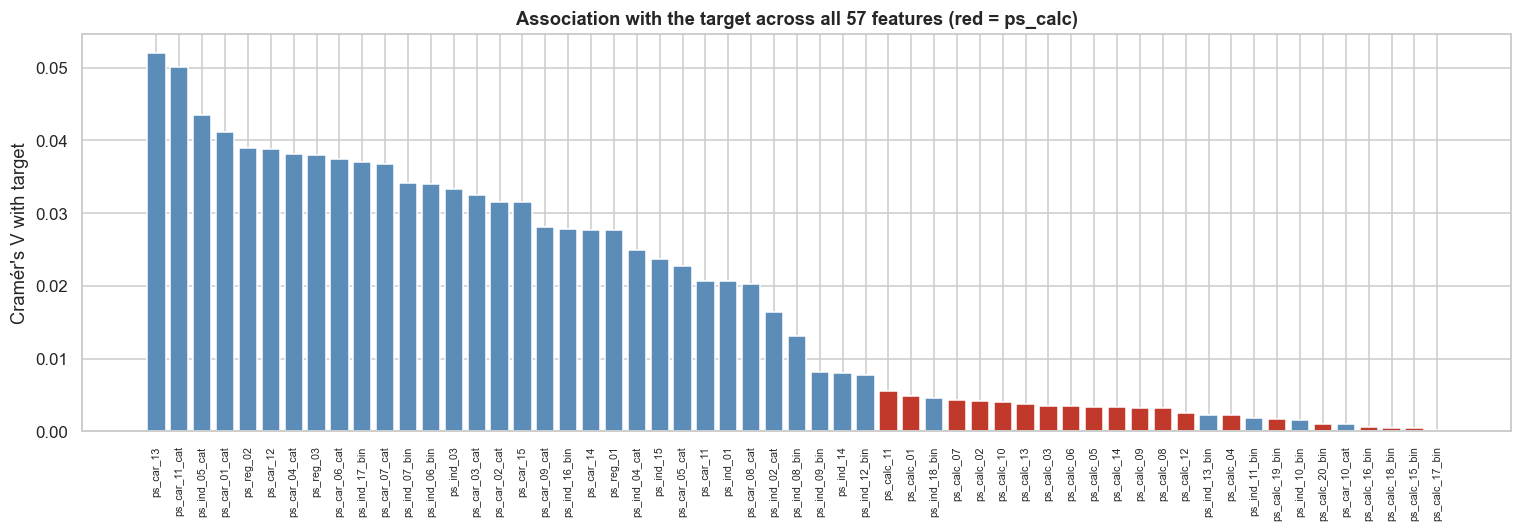

In [76]:
assoc = pd.DataFrame(rows).sort_values("v", ascending=False)

plt.figure(figsize=(14, 5))
colors = [PALETTE[1] if b == "ps_calc" else PALETTE[0] for b in assoc["block"]]
plt.bar(assoc["feature"], assoc["v"], color=colors)
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("Cramér's V with target")
plt.title("Association with the target across all 57 features (red = ps_calc)")
plt.grid(True, axis="y", zorder=-3)
plt.tight_layout()
plt.savefig(FIGDIR / "all_features_association.png", dpi=150, bbox_inches="tight")
plt.show()

### Preprocessing decisions derived from the EDA

| EDA finding | Decision |
|---|---|
| Missingness is informative | Preserve it: `-1` as an explicit level for categoricals, missing indicators for numerical features, and an engineered `n_missing` count |
| `ps_calc_*` shows little marginal signal | Compare models with and without the `calc` block rather than dropping it outright |
| `ps_car_11_cat` has 104 levels | Compare one-hot encoding against target encoding |
| `ps_reg_*` and `ps_car_12`–`15` are correlated | Retain them, but account for the redundancy when interpreting feature importance |
| No single feature strongly separates the classes | Include non-linear tree-based models able to capture interactions |
| Binary features have no missing values | Pass them through unchanged |

# 2. Data Processing : 

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

### 2.1 Train/test split:

In [31]:
for c in df.columns:
    if str(df[c].dtype) == "category":
        df[c] = pd.to_numeric(df[c].astype(str), errors="coerce")

print(df.dtypes.value_counts())  

float64    35
int64      23
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

y = pd.to_numeric(df[TARGET]).astype(int)
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("train:", X_train.shape, "| positive rate: %.4f" % y_train.mean())

train: (476169, 57) | positive rate: 0.0364


### 2.2 Feature engineering:

In [33]:
def add_features(X):
    out = X.copy()
    # Missingness is informative (seen on ps_car_01/07/09_cat).
    out["n_missing"] = X.isna().sum(axis=1)
    return out

X_train = add_features(X_train)
X_test  = add_features(X_test)
num_feats = numeric_cols + ["n_missing"]

print("n_missing" in X_train.columns, len(num_feats))

True 27


### 2.3 Preprocessing for Logistic Regression:

Testing different encoding combination : 

In [35]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])

preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipeline, num_feats),
    ("bin", "passthrough", binary_cols),   # no NaN, already 0/1, no scaling needed
    ("cat", categorical_pipeline, categorical_cols),
])

In [36]:
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold

high_card = ["ps_car_11_cat"]
low_card  = [c for c in categorical_cols if c not in high_card]

def make_lr_pipeline(te_cols):
    """Logistic regression pipeline; te_cols get target encoding, the rest one-hot."""
    oh_cols = [c for c in categorical_cols if c not in te_cols]
    transformers = [
        ("num", numeric_pipeline, num_feats),
        ("bin", "passthrough", binary_cols),
    ]
    if oh_cols:
        transformers.append(("cat_oh", categorical_pipeline, oh_cols))
    if te_cols:
        transformers.append(("cat_te", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value=-1)),
            ("te", TargetEncoder(smooth="auto", cv=StratifiedKFold(5, shuffle=True, random_state=42))),
            ("sc", StandardScaler()),
        ]), te_cols))
    return Pipeline([
        ("pre", ColumnTransformer(transformers)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

variants = {
    "one-hot only":        make_lr_pipeline([]),
    "TE on high-card only": make_lr_pipeline(high_card),
    "TE on all categoricals": make_lr_pipeline(categorical_cols),
}

for name, pipe in variants.items():
    auc = cross_val_score(pipe, X_train, y_train, cv=cv,
                          scoring="roc_auc", n_jobs=-1)
    print(f"{name:25s} | Gini {2*auc.mean()-1:.4f} (+/- {2*auc.std():.4f})")

one-hot only              | Gini 0.2571 (+/- 0.0058)
TE on high-card only      | Gini 0.2574 (+/- 0.0053)
TE on all categoricals    | Gini 0.2525 (+/- 0.0038)


### 2.4 Preprocessing for XGBoost

In [37]:
def prepare_xgb(X, categories=None):
    out = X.copy()
    # Missing stays an explicit level for categoricals, NaN for numerics.
    for c in categorical_cols:
        filled = out[c].fillna(-1).astype(int)
        out[c] = (pd.Categorical(filled, categories=categories[c])
                  if categories else filled.astype("category"))
    return out

X_train_xgb = prepare_xgb(X_train)
cats = {c: X_train_xgb[c].cat.categories for c in categorical_cols}
X_test_xgb = prepare_xgb(X_test, categories=cats)

### 2.5 Preprocessing for Random Forest:

In [38]:
preprocessor_rf = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", add_indicator=True), num_feats),
    ("bin", "passthrough", binary_cols),
    ("cat", SimpleImputer(strategy="constant", fill_value=-1), categorical_cols),
])

### 2.6 Learning curves :

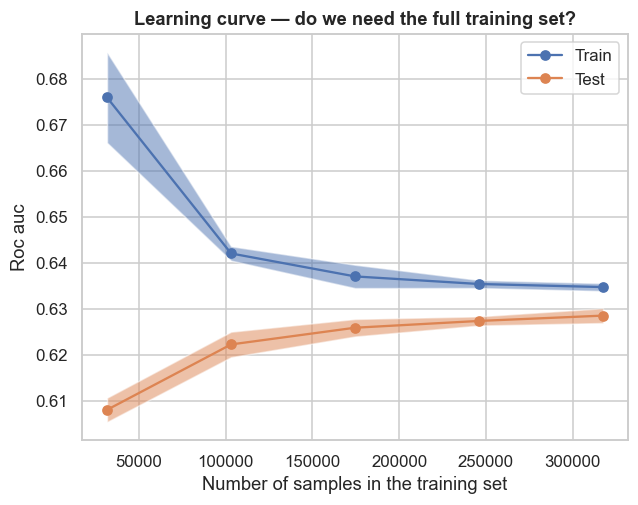

In [39]:
from sklearn.model_selection import LearningCurveDisplay
LearningCurveDisplay.from_estimator(
    make_lr_pipeline([]),          # empty list = one-hot only, no target encoding
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3, scoring="roc_auc", n_jobs=-1,
    score_type="both", line_kw={"marker": "o"},
)
plt.title("Learning curve — do we need the full training set?")
plt.grid(True, zorder=-3)
plt.show()

# 3. Modeling

In [40]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_fscore_support, roc_curve, precision_recall_curve)
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, ValidationCurveDisplay, LearningCurveDisplay)
from sklearn.base import clone

### Helper functions:

In [41]:
cv_hpo = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def run_search(estimator, param_grid, X, y, search="grid",
               n_iter=20, cv=cv_hpo, verbose=0):
    """Grid or randomized search, returns the fitted search object."""
    common = dict(scoring={"auc": "roc_auc", "ap": "average_precision"},
                  cv=cv, verbose=verbose, error_score="raise",
                  refit="auc", n_jobs=-1)
    s = (GridSearchCV(estimator, param_grid, **common) if search == "grid"
         else RandomizedSearchCV(estimator, param_grid, n_iter=n_iter,
                                 random_state=42, **common))
    s.fit(X, y)

    res = pd.DataFrame(s.cv_results_)
    param_cols = [c for c in res.columns if c.startswith("param_")]

    def fmt_params(row):
        parts = []
        for c in param_cols:
            name = c.replace("param_model__", "").replace("param_", "")
            v = row[c]
            v = "None" if pd.isna(v) else (f"{v:g}" if isinstance(v, (int, float)) else str(v))
            parts.append(f"{name}={v}")
        return ", ".join(parts)

    res["label"] = res.apply(fmt_params, axis=1)
    res["gini"] = 2 * res["mean_test_auc"] - 1
    res = res.sort_values("mean_test_auc", ascending=False)

    width = max(res["label"].str.len().max(), 10)
    print(f"{len(res)} candidates x {cv.get_n_splits()} folds\n")
    print(f"{'PARAMETERS':<{width}} | {'AUC':>7} | {'GINI':>7} | {'AP':>7}")
    print("-" * (width + 30))
    for _, r in res.iterrows():
        print(f"{r['label']:<{width}} | {r['mean_test_auc']:>7.4f} "
              f"| {r['gini']:>7.4f} | {r['mean_test_ap']:>7.4f}")

    best = res.iloc[0]
    print("\nBest by AUC/Gini")
    print(f"  {best['label']}")
    print(f"  AUC {best['mean_test_auc']:.4f} | Gini {best['gini']:.4f} "
          f"| AP {best['mean_test_ap']:.4f}")

    top_ap = res.loc[res["mean_test_ap"].idxmax()]
    if top_ap["label"] != best["label"]:
        print("\nBest by AP")
        print(f"  {top_ap['label']}")
        print(f"  AUC {top_ap['mean_test_auc']:.4f} | Gini {top_ap['gini']:.4f} "
              f"| AP {top_ap['mean_test_ap']:.4f}")
        print("\n  The two metrics disagree; the refitted model uses AUC.")

    return s

In [42]:
def evaluate(y_true, y_proba, threshold=None):
    auc = roc_auc_score(y_true, y_proba)
    print(f"AUC          : {auc:.4f}")
    print(f"Gini         : {2*auc-1:.4f}")
    print(f"Avg Precision: {average_precision_score(y_true, y_proba):.4f}  "
          f"(baseline = {y_true.mean():.4f})")

    if threshold is not None:
        pred = (y_proba >= threshold).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, pred, average="binary", zero_division=0)
        print(f"\nAt threshold {threshold:.3f}:")
        print(f"  precision {p:.4f} | recall {r:.4f} | F1 {f1:.4f}")

### 3.1 Logistic Regression

#### __Baseline Model:__

In [43]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=1000))
])

In [44]:
lr_pipeline.fit(X_train, y_train)
proba = lr_pipeline.predict_proba(X_test)[:, 1]
evaluate(y_test, proba)

AUC          : 0.6320
Gini         : 0.2641
Avg Precision: 0.0655  (baseline = 0.0364)


#### __GridSearch__:

In [45]:
gs_lr = run_search(
    estimator=clone(lr_pipeline),
    param_grid={
        "model__C": np.logspace(-3, 2, 6),
        "model__class_weight": ["balanced", None],
    },
    X=X_train, y=y_train,
    search="grid", verbose=0,
)

12 candidates x 3 folds

PARAMETERS                     |     AUC |    GINI |      AP
------------------------------------------------------------
C=0.001, class_weight=balanced |  0.6281 |  0.2562 |  0.0620
C=0.01, class_weight=balanced  |  0.6280 |  0.2560 |  0.0626
C=0.1, class_weight=None       |  0.6278 |  0.2557 |  0.0633
C=0.1, class_weight=balanced   |  0.6278 |  0.2555 |  0.0628
C=1, class_weight=balanced     |  0.6277 |  0.2555 |  0.0628
C=10, class_weight=balanced    |  0.6277 |  0.2555 |  0.0628
C=100, class_weight=balanced   |  0.6277 |  0.2555 |  0.0628
C=1, class_weight=None         |  0.6276 |  0.2553 |  0.0632
C=0.01, class_weight=None      |  0.6276 |  0.2552 |  0.0631
C=100, class_weight=None       |  0.6276 |  0.2552 |  0.0632
C=10, class_weight=None        |  0.6276 |  0.2552 |  0.0632
C=0.001, class_weight=None     |  0.6266 |  0.2532 |  0.0609

Best by AUC/Gini
  C=0.001, class_weight=balanced
  AUC 0.6281 | Gini 0.2562 | AP 0.0620

Best by AP
  C=0.1, class_weig

### 3.2 XGBoost

#### __Baseline Model:__

In [46]:
model_xgb = xgb.XGBClassifier(
    enable_categorical=True,
    tree_method="hist",
    eval_metric="auc",
    random_state=42
)

model_xgb.fit(X_train_xgb, y_train)

proba = model_xgb.predict_proba(X_test_xgb)[:, 1]

evaluate(y_test, proba)

AUC          : 0.5935
Gini         : 0.1869
Avg Precision: 0.0554  (baseline = 0.0364)


#### __GridSearch :__ 

In [47]:
rs_xgb = run_search(
    estimator=clone(model_xgb),

    param_grid={
        "n_estimators": [800, 1200, 1600, 2000],
        "learning_rate": [0.01, 0.02, 0.03],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [10, 30, 50, 100],
        "reg_alpha": [0, 0.1, 1, 5],
        "reg_lambda": [1, 10, 50],
    },

    X=X_train_xgb,
    y=y_train,

    search="random",
    n_iter=25,
    verbose=0,
)

25 candidates x 3 folds

PARAMETERS                                                                                                                                 |     AUC |    GINI |      AP
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
subsample=1, reg_lambda=1, reg_alpha=5, n_estimators=1600, min_child_weight=100, max_depth=5, learning_rate=0.01, colsample_bytree=0.6     |  0.6367 |  0.2735 |  0.0654
subsample=1, reg_lambda=10, reg_alpha=5, n_estimators=2000, min_child_weight=30, max_depth=4, learning_rate=0.01, colsample_bytree=0.6     |  0.6365 |  0.2730 |  0.0655
subsample=0.8, reg_lambda=10, reg_alpha=0.1, n_estimators=1200, min_child_weight=30, max_depth=4, learning_rate=0.01, colsample_bytree=0.6 |  0.6341 |  0.2682 |  0.0651
subsample=0.6, reg_lambda=1, reg_alpha=5, n_estimators=1600, min_child_weight=30, max_depth=6, learning_rate=0.01, colsample_bytre

#### __Feature importance :__

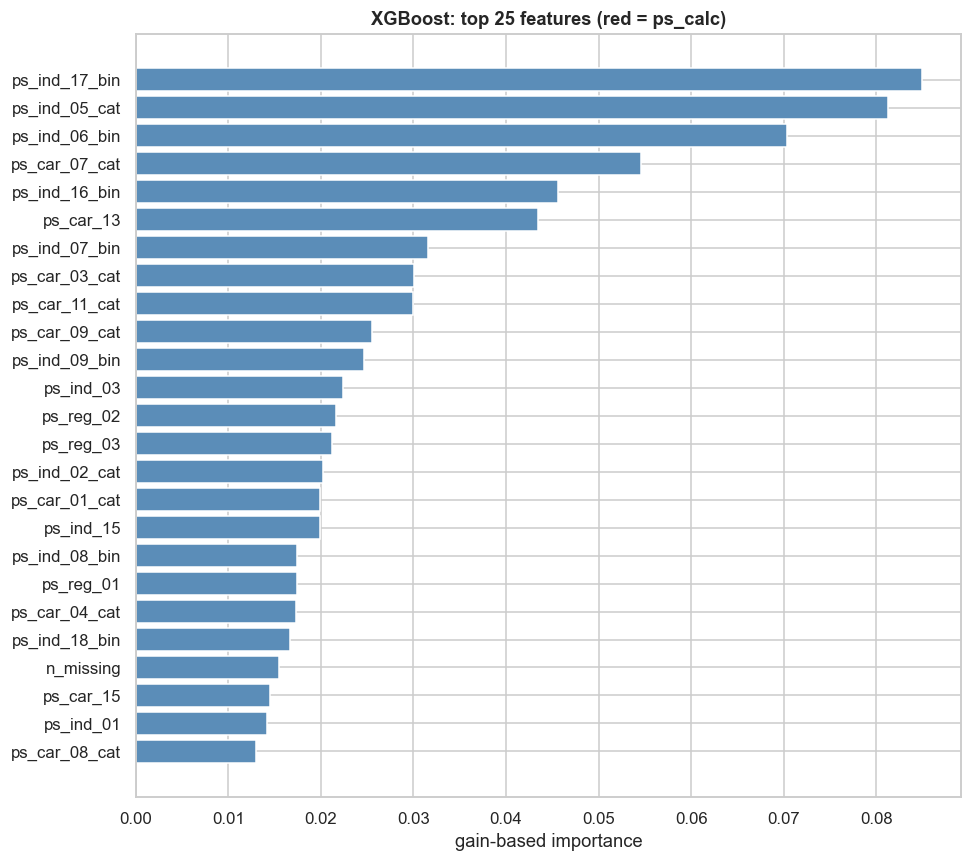

Feature importance:
ps_ind_17_bin     0.084945
ps_ind_05_cat     0.081297
ps_ind_06_bin     0.070306
ps_car_07_cat     0.054576
ps_ind_16_bin     0.045605
ps_car_13         0.043453
ps_ind_07_bin     0.031566
ps_car_03_cat     0.030085
ps_car_11_cat     0.030003
ps_car_09_cat     0.025533
ps_ind_09_bin     0.024612
ps_ind_03         0.022440
ps_reg_02         0.021603
ps_reg_03         0.021202
ps_ind_02_cat     0.020205
ps_car_01_cat     0.019925
ps_ind_15         0.019868
ps_ind_08_bin     0.017443
ps_reg_01         0.017391
ps_car_04_cat     0.017349
ps_ind_18_bin     0.016665
n_missing         0.015422
ps_car_15         0.014472
ps_ind_01         0.014125
ps_car_08_cat     0.013028
ps_car_06_cat     0.011599
ps_ind_04_cat     0.011036
ps_car_05_cat     0.010123
ps_car_14         0.009348
ps_calc_05        0.008826
ps_car_02_cat     0.008797
ps_calc_19_bin    0.008707
ps_car_12         0.008673
ps_calc_06        0.008501
ps_calc_18_bin    0.008266
ps_car_11         0.008144
ps_calc_

In [48]:
best_xgb = rs_xgb.best_estimator_

imp = pd.Series(
    best_xgb.feature_importances_,
    index=X_train_xgb.columns
).sort_values(ascending=False)

# --- Plot: top 25 only ---
top = imp.head(25).sort_values()

colors = [
    PALETTE[1] if "calc" in c else PALETTE[0]
    for c in top.index
]

plt.figure(figsize=(9, 8))

bars = plt.barh(top.index, top.values, color=colors)

plt.xlabel("gain-based importance")
plt.title("XGBoost: top 25 features (red = ps_calc)")
plt.tight_layout()

plt.savefig(
    FIGDIR / "xgb_feature_importance_top25.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --- Print: ALL features ---
print("Feature importance:")
print(imp.to_string())

calc_total = imp[
    imp.index.str.contains("calc")
].sum()

print(f"\nTotal importance of ps_calc block: {calc_total:.4f}")

### 3.3 Random Forest : 

#### __Baseline Model:__

In [49]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    )),
])

rf_pipeline.fit(X_train, y_train)
proba_rf_base = rf_pipeline.predict_proba(X_test)[:, 1]
evaluate(y_test, proba_rf_base)

AUC          : 0.6041
Gini         : 0.2081
Avg Precision: 0.0554  (baseline = 0.0364)


#### __GridSearch :__

In [50]:
rs_rf = run_search(
    estimator=clone(rf_pipeline),
    param_grid={
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [6, 10, 15, 20, None],
        "model__min_samples_leaf": [1, 10, 50, 100],
        "model__max_features": [0.2, 0.3, 0.5, "sqrt"],
        "model__class_weight": ["balanced_subsample", None],
    },
    X=X_train, y=y_train,
    search="random", n_iter=20,
)

20 candidates x 3 folds

PARAMETERS                                                                                                |     AUC |    GINI |      AP
---------------------------------------------------------------------------------------------------------------------------------------
n_estimators=400, min_samples_leaf=100, max_features=0.2, max_depth=20, class_weight=None                 |  0.6335 |  0.2671 |  0.0637
n_estimators=600, min_samples_leaf=100, max_features=0.2, max_depth=None, class_weight=balanced_subsample |  0.6334 |  0.2669 |  0.0632
n_estimators=400, min_samples_leaf=100, max_features=0.2, max_depth=None, class_weight=None               |  0.6333 |  0.2665 |  0.0635
n_estimators=400, min_samples_leaf=100, max_features=0.2, max_depth=10, class_weight=None                 |  0.6320 |  0.2640 |  0.0633
n_estimators=200, min_samples_leaf=100, max_features=sqrt, max_depth=10, class_weight=balanced_subsample  |  0.6281 |  0.2561 |  0.0615
n_estimators=200, min_s

#### __Feature importance :__

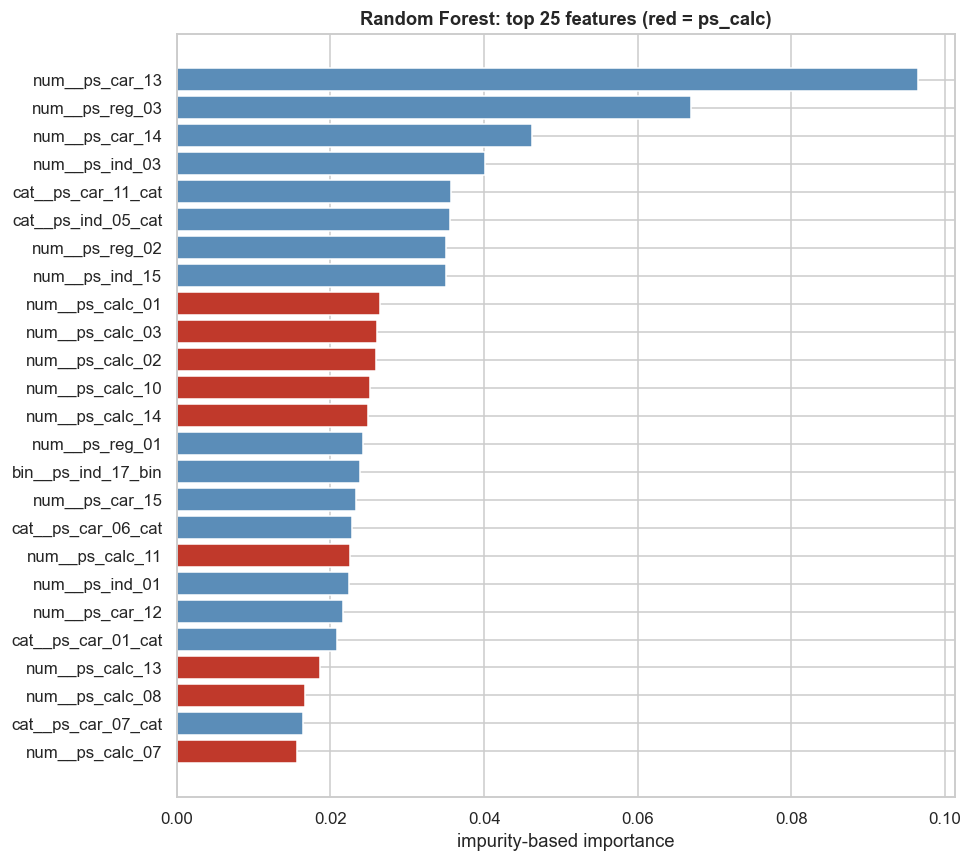

Feature importance:
num__ps_car_13                     0.096496
num__ps_reg_03                     0.066972
num__ps_car_14                     0.046243
num__ps_ind_03                     0.040098
cat__ps_car_11_cat                 0.035694
cat__ps_ind_05_cat                 0.035517
num__ps_reg_02                     0.035057
num__ps_ind_15                     0.035014
num__ps_calc_01                    0.026421
num__ps_calc_03                    0.026030
num__ps_calc_02                    0.025901
num__ps_calc_10                    0.025147
num__ps_calc_14                    0.024833
num__ps_reg_01                     0.024212
bin__ps_ind_17_bin                 0.023866
num__ps_car_15                     0.023354
cat__ps_car_06_cat                 0.022822
num__ps_calc_11                    0.022560
num__ps_ind_01                     0.022474
num__ps_car_12                     0.021592
cat__ps_car_01_cat                 0.020784
num__ps_calc_13                    0.018618
num__ps_calc

In [51]:
best_rf = rs_rf.best_estimator_

feat_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

imp = pd.Series(
    best_rf.named_steps["model"].feature_importances_,
    index=feat_names
).sort_values(ascending=False)

# Top 25 for the plot
top = imp.head(25).sort_values()

colors = [
    PALETTE[1] if "calc" in c else PALETTE[0]
    for c in top.index
]

plt.figure(figsize=(9, 8))

plt.barh(
    top.index,
    top.values,
    color=colors
)

plt.xlabel("impurity-based importance")
plt.title("Random Forest: top 25 features (red = ps_calc)")
plt.tight_layout()

plt.savefig(
    FIGDIR / "rf_feature_importance_top25.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Print ALL features
print("Feature importance:")
print(imp.to_string())

# Total importance of ps_calc block
calc_total = imp[
    imp.index.str.contains("calc")
].sum()

print(f"\nps_calc total importance: {calc_total:.4f}")

### 3.4 Model comparison :

Evaluation of the tuned model on test set : 

In [52]:
proba_lr  = gs_lr.best_estimator_.predict_proba(X_test)[:, 1]
proba_rf  = rs_rf.best_estimator_.predict_proba(X_test)[:, 1]
proba_xgb = rs_xgb.best_estimator_.predict_proba(X_test_xgb)[:, 1]

for name, p in [("LR", proba_lr), ("RF", proba_rf), ("XGBoost", proba_xgb)]:
    auc = roc_auc_score(y_test, p)
    print(f"{name:<10} | AUC {auc:.4f} | Gini {2*auc-1:.4f} "
          f"| AP {average_precision_score(y_test, p):.4f}")

LR         | AUC 0.6324 | Gini 0.2648 | AP 0.0637
RF         | AUC 0.6345 | Gini 0.2689 | AP 0.0648
XGBoost    | AUC 0.6413 | Gini 0.2825 | AP 0.0676


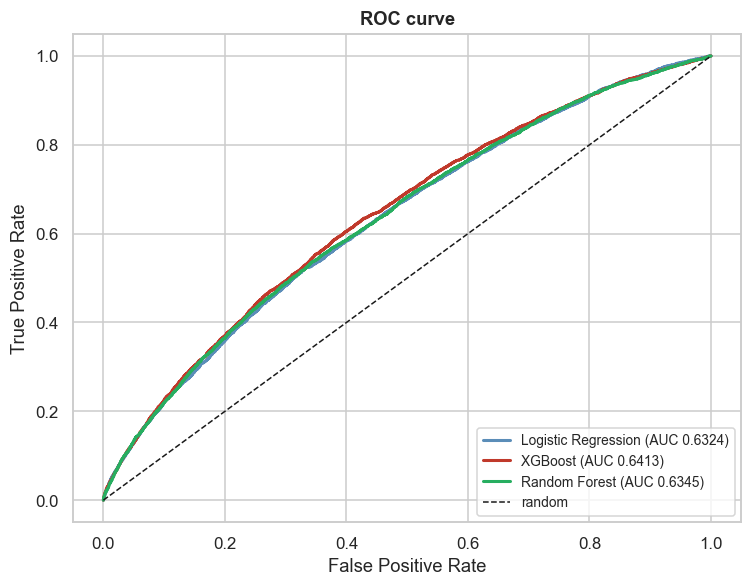

In [53]:
models = [
    ("Logistic Regression", proba_lr,  "#5b8db8", "-"),
    ("XGBoost",             proba_xgb, "#c0392b", "--"),
    ("Random Forest",       proba_rf,  "#27ae60", ":"),
]
plt.figure(figsize=(7, 5.5))
for name, p, color, ls in models:
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    plt.plot(fpr, tpr, color=color, ls="-", lw=2,
             label=f"{name} (AUC {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, zorder=-3)
plt.tight_layout()
plt.savefig(FIGDIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

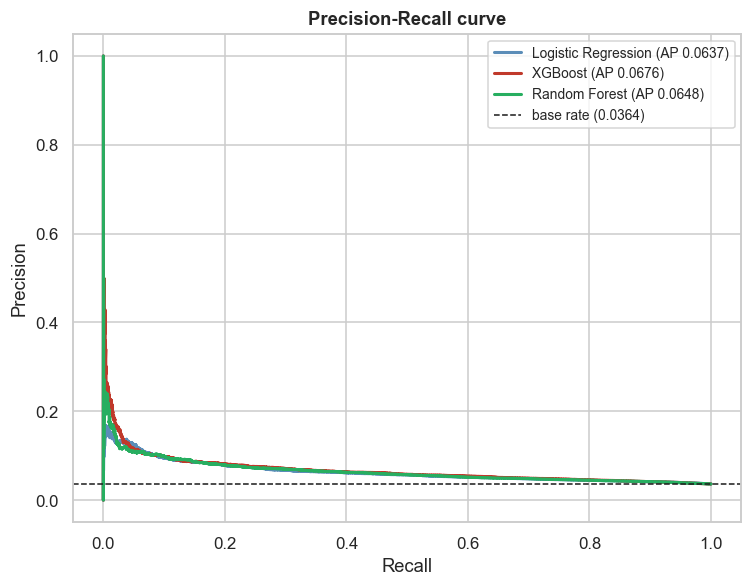

In [54]:
plt.figure(figsize=(7, 5.5))
for name, p, color, ls in models:
    precision, recall, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    plt.plot(recall, precision, color=color, ls="-", lw=2,
             label=f"{name} (AP {ap:.4f})")

plt.axhline(y_test.mean(), color="k", ls="--", lw=1,
            label=f"base rate ({y_test.mean():.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, zorder=-3)
plt.tight_layout()
plt.savefig(FIGDIR / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

/Users/leyla.louache/Documents/Uni/advanced-data-analytics/ADA/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


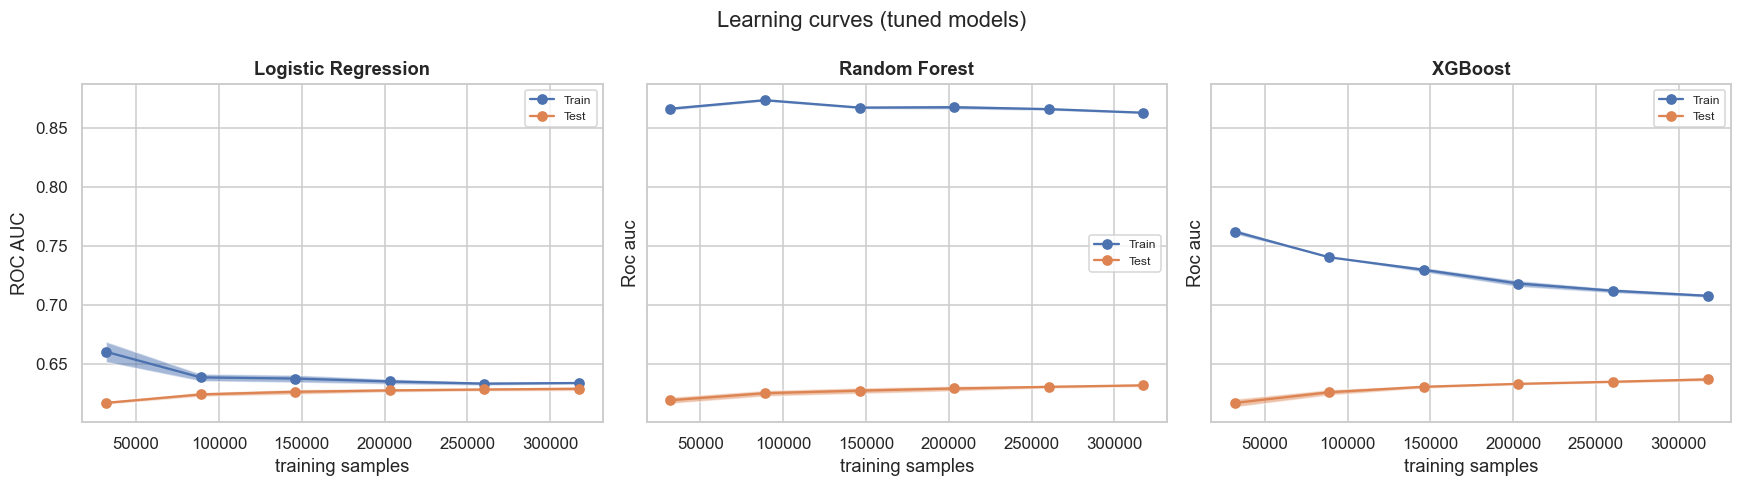

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

curves = [
    ("Logistic Regression", gs_lr.best_estimator_,  X_train,     axes[0]),
    ("Random Forest",       rs_rf.best_estimator_,  X_train,     axes[1]),
    ("XGBoost",             rs_xgb.best_estimator_, X_train_xgb, axes[2]),
]

for name, model, X, ax in curves:
    LearningCurveDisplay.from_estimator(
        clone(model), X, y_train,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=3, scoring="roc_auc", n_jobs=-1,
        score_type="both",
        std_display_style="fill_between",
        line_kw={"marker": "o"},
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("training samples")
    ax.grid(True, zorder=-3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("ROC AUC")
fig.suptitle("Learning curves (tuned models)")
plt.tight_layout()
plt.savefig(FIGDIR / "learning_curves_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Custom Stack

### Helper function: 

In [55]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import StackingClassifier

def to_category(X):
    """Convert categorical columns to pandas category dtype for XGBoost."""
    out = X.copy()
    for c in out.columns:
        if c.endswith("_cat"):
            out[c] = out[c].fillna(-1).astype(int).astype("category")
    return out

In [64]:
def build_models(feats):
    """Rebuild each pipeline so its preprocessor matches the given feature set."""
    num_f = [c for c in num_feats if c in feats]
    cat_f = [c for c in categorical_cols if c in feats]
    bin_f = [c for c in binary_cols if c in feats]

    lr = Pipeline([
        ("pre", ColumnTransformer([
            ("num", numeric_pipeline, num_f),
            ("bin", "passthrough", bin_f),
            ("cat", categorical_pipeline, cat_f),
        ])),
        ("model", clone(gs_lr.best_estimator_.named_steps["model"])),
    ])

    rf = Pipeline([
        ("pre", ColumnTransformer([
            ("num", SimpleImputer(strategy="median", add_indicator=True), num_f),
            ("bin", "passthrough", bin_f),
            ("cat", SimpleImputer(strategy="constant", fill_value=-1), cat_f),
        ])),
        ("model", clone(rs_rf.best_estimator_.named_steps["model"])),
    ])

    xgb_m = clone(rs_xgb.best_estimator_)

    return [("lr", lr, X_train, X_test),
            ("rf", rf, X_train, X_test),
            ("xgb", xgb_m, X_train_xgb, X_test_xgb)]

### Stacking : 

In [65]:
calc_cols_all = [c for c in X_train.columns if c.startswith("ps_calc")]
variants = {
    "with calc":    list(X_train.columns),
    "without calc": [c for c in X_train.columns if c not in calc_cols_all],
}

cv_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"with calc: {len(variants['with calc'])} | "
      f"without calc: {len(variants['without calc'])}")

with calc: 58 | without calc: 38


In [67]:
from sklearn.model_selection import cross_val_predict

cv_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for vname, feats in variants.items():
    oof, test_pred = {}, {}
    for name, model, Xtr, Xte in build_models(feats):
        oof[name] = cross_val_predict(model, Xtr[feats], y_train, cv=cv_stack,
                                      method="predict_proba", n_jobs=-1)[:, 1]
        model.fit(Xtr[feats], y_train)
        test_pred[name] = model.predict_proba(Xte[feats])[:, 1]

    meta = Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(max_iter=1000))])
    meta.fit(pd.DataFrame(oof), y_train)
    test_pred["stack"] = meta.predict_proba(pd.DataFrame(test_pred))[:, 1]

    results[vname] = test_pred
    w = [float(x) for x in meta.named_steps["lr"].coef_[0].round(3)]
    print(f"{vname:14s} | {len(feats)} features | meta weights {dict(zip(oof, w))}")

with calc      | 58 features | meta weights {'lr': 0.178, 'rf': 0.128, 'xgb': 0.144}
without calc   | 38 features | meta weights {'lr': 0.178, 'rf': 0.128, 'xgb': 0.145}


### __Evaluation of all final models :__

In [68]:
rows = []
for vname, preds in results.items():
    for mname, p in preds.items():
        auc = roc_auc_score(y_test, p)
        rows.append({"model": mname, "variant": vname,
                     "auc": auc, "gini": 2*auc - 1,
                     "ap": average_precision_score(y_test, p)})

comp = pd.DataFrame(rows)
order = ["lr", "rf", "xgb", "stack"]
labels = {"lr": "Logistic Reg.", "rf": "Random Forest",
          "xgb": "XGBoost", "stack": "Stacking"}

print(f"{'MODEL':<16} | {'VARIANT':<13} | {'AUC':>7} | {'GINI':>7} | {'AP':>7}")
print("-" * 62)
for m in order:
    for v in ["with calc", "without calc"]:
        r = comp[(comp["model"] == m) & (comp["variant"] == v)].iloc[0]
        print(f"{labels[m]:<16} | {v:<13} | {r['auc']:>7.4f} "
              f"| {r['gini']:>7.4f} | {r['ap']:>7.4f}")
    print("-" * 62)

pivot = comp.pivot(index="model", columns="variant", values="gini")
pivot["delta"] = pivot["without calc"] - pivot["with calc"]
print("\nGini delta (without − with):")
print(pivot.loc[order].round(4))

MODEL            | VARIANT       |     AUC |    GINI |      AP
--------------------------------------------------------------
Logistic Reg.    | with calc     |  0.6324 |  0.2648 |  0.0637
Logistic Reg.    | without calc  |  0.6331 |  0.2663 |  0.0640
--------------------------------------------------------------
Random Forest    | with calc     |  0.6345 |  0.2689 |  0.0648
Random Forest    | without calc  |  0.6339 |  0.2677 |  0.0651
--------------------------------------------------------------
XGBoost          | with calc     |  0.6413 |  0.2825 |  0.0676
XGBoost          | without calc  |  0.6423 |  0.2846 |  0.0683
--------------------------------------------------------------
Stacking         | with calc     |  0.6403 |  0.2807 |  0.0677
Stacking         | without calc  |  0.6409 |  0.2819 |  0.0682
--------------------------------------------------------------

Gini delta (without − with):
variant  with calc  without calc   delta
model                                   
lr    

__Plot__ : 

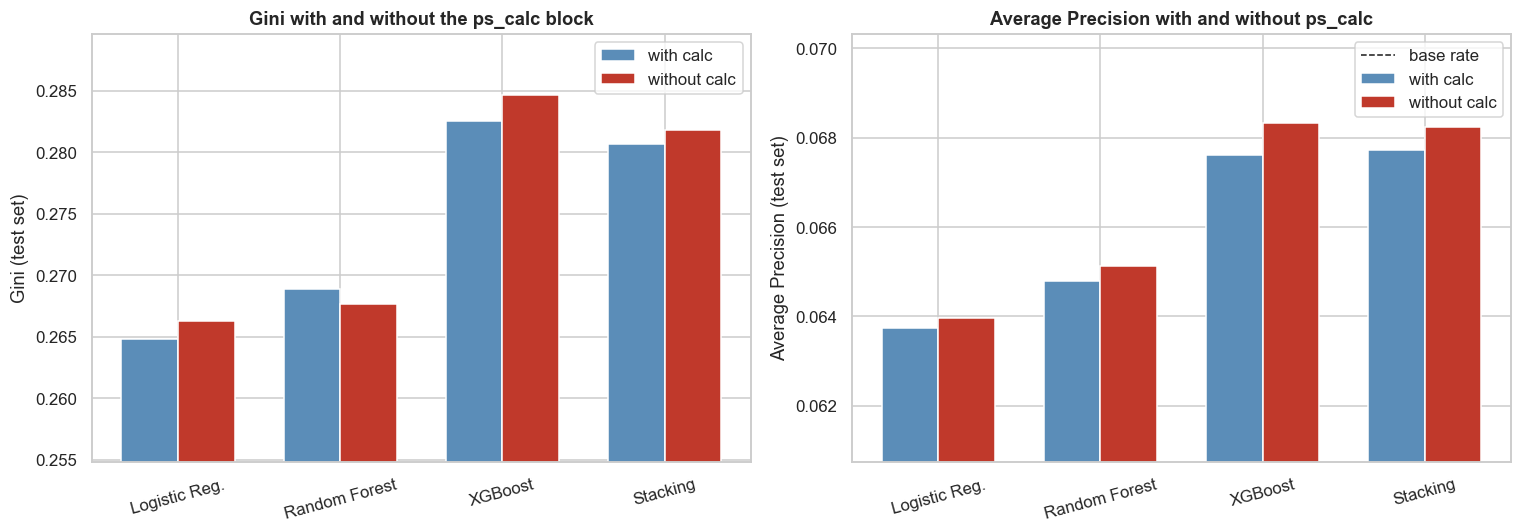

In [69]:
x = np.arange(len(order))
w_bar = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gini for both variants
g_with = [pivot.loc[m, "with calc"] for m in order]
g_without = [pivot.loc[m, "without calc"] for m in order]

ax1.bar(x - w_bar/2, g_with, w_bar, label="with calc", color="#5b8db8")
ax1.bar(x + w_bar/2, g_without, w_bar, label="without calc", color="#c0392b")
ax1.set_xticks(x)
ax1.set_xticklabels([labels[m] for m in order], rotation=15)
ax1.set_ylabel("Gini (test set)")
ax1.set_ylim(min(g_with + g_without) - 0.01, max(g_with + g_without) + 0.005)
ax1.set_title("Gini with and without the ps_calc block")
ax1.legend()
ax1.grid(True, axis="y", zorder=-3)

# Right: AP for both variants
ap = comp.pivot(index="model", columns="variant", values="ap")
a_with = [ap.loc[m, "with calc"] for m in order]
a_without = [ap.loc[m, "without calc"] for m in order]

ax2.bar(x - w_bar/2, a_with, w_bar, label="with calc", color="#5b8db8")
ax2.bar(x + w_bar/2, a_without, w_bar, label="without calc", color="#c0392b")
ax2.set_xticks(x)
ax2.set_xticklabels([labels[m] for m in order], rotation=15)
ax2.set_ylabel("Average Precision (test set)")
ax2.set_ylim(min(a_with + a_without) - 0.003, max(a_with + a_without) + 0.002)
ax2.axhline(y_test.mean(), color="k", ls="--", lw=1, label="base rate")
ax2.set_title("Average Precision with and without ps_calc")
ax2.legend()
ax2.grid(True, axis="y", zorder=-3)

plt.tight_layout()
plt.savefig(FIGDIR / "calc_ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

__Correlation between models:__

In [70]:
print(pd.DataFrame(oof).corr(method="spearman").round(3))

        lr     rf    xgb
lr   1.000  0.877  0.871
rf   0.877  1.000  0.900
xgb  0.871  0.900  1.000


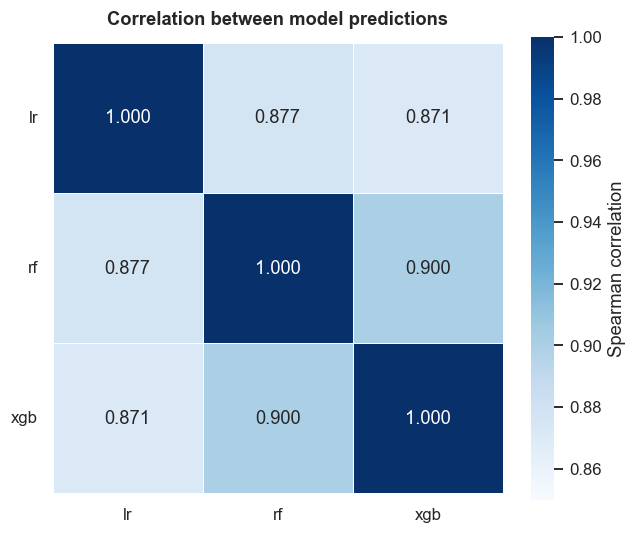

In [80]:
corr = pd.DataFrame(oof).corr(method="spearman")

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.85, vmax=1.0,        # tight range: all values sit above 0.87
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title("Correlation between model predictions", pad=12)
plt.tight_layout()
plt.savefig(FIGDIR / "base_model_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### Best final model (XGBOOST/ Without CALC):

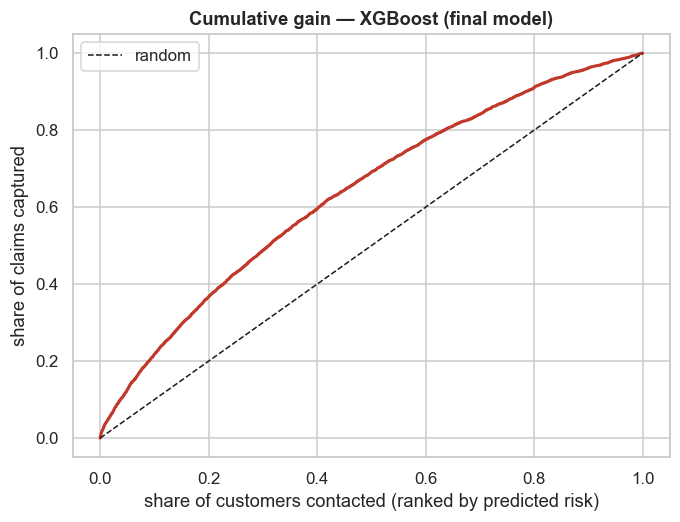

top 10% -> 21.8% of claims
top 20% -> 36.7% of claims
top 30% -> 48.8% of claims


In [71]:
best = results["without calc"]["xgb"]
y_sorted = y_test.values[np.argsort(-best)]
cum = np.cumsum(y_sorted) / y_sorted.sum()

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(y_sorted)+1)/len(y_sorted), cum, color="#c0392b", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("share of customers contacted (ranked by predicted risk)")
plt.ylabel("share of claims captured")
plt.title("Cumulative gain — XGBoost (final model)")
plt.legend(); plt.grid(True, zorder=-3)
plt.show()

for q in [0.1, 0.2, 0.3]:
    print(f"top {q:.0%} -> {cum[int(q*len(y_sorted))]:.1%} of claims")

### Save results:

In [72]:
import json
from pathlib import Path
from datetime import datetime

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def clean_params(params):
    """JSON cannot serialise numpy scalars or sklearn objects."""
    out = {}
    for k, v in params.items():
        if isinstance(v, (np.integer,)):
            out[k] = int(v)
        elif isinstance(v, (np.floating,)):
            out[k] = float(v)
        elif isinstance(v, (str, int, float, bool, type(None))):
            out[k] = v
        else:
            out[k] = str(v)
    return out


def score_entry(name, y_true, y_proba, params=None, notes=None):
    auc = roc_auc_score(y_true, y_proba)
    return {
        "model": name,
        "auc": round(float(auc), 4),
        "gini": round(float(2 * auc - 1), 4),
        "ap": round(float(average_precision_score(y_true, y_proba)), 4),
        "base_rate": round(float(y_true.mean()), 4),
        "params": clean_params(params) if params else {},
        "notes": notes,
    }

In [73]:
NOTEBOOK_ID = "01"

all_results = [
    score_entry("Logistic Regression", y_test, results["with calc"]["lr"],
                gs_lr.best_params_, notes="with calc"),
    score_entry("Logistic Regression", y_test, results["without calc"]["lr"],
                gs_lr.best_params_, notes="without calc"),

    score_entry("Random Forest", y_test, results["with calc"]["rf"],
                rs_rf.best_params_, notes="with calc"),
    score_entry("Random Forest", y_test, results["without calc"]["rf"],
                rs_rf.best_params_, notes="without calc"),

    score_entry("XGBoost", y_test, results["with calc"]["xgb"],
                rs_xgb.best_params_, notes="with calc"),
    score_entry("XGBoost", y_test, results["without calc"]["xgb"],
                rs_xgb.best_params_, notes="without calc"),

    score_entry("Stacking", y_test, results["with calc"]["stack"],
                {"base": "lr+rf+xgb", "meta": "LogisticRegression"},
                notes="with calc"),
    score_entry("Stacking", y_test, results["without calc"]["stack"],
                {"base": "lr+rf+xgb", "meta": "LogisticRegression"},
                notes="without calc"),
]

path = RESULTS_DIR / f"{NOTEBOOK_ID}_models.json"
with open(path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved in {path}")
print(pd.DataFrame(all_results)[["model", "notes", "gini", "ap"]].to_string(index=False))

Results saved in ../results/01_models.json
              model        notes   gini     ap
Logistic Regression    with calc 0.2648 0.0637
Logistic Regression without calc 0.2663 0.0640
      Random Forest    with calc 0.2689 0.0648
      Random Forest without calc 0.2677 0.0651
            XGBoost    with calc 0.2825 0.0676
            XGBoost without calc 0.2846 0.0683
           Stacking    with calc 0.2807 0.0677
           Stacking without calc 0.2819 0.0682
